# Ext. Fig. 5: Teleport analysis

Tested and works but could use some cleanup and modularization

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import sys
import os
import pickle
import dill
import numpy as np
import scipy as sp
import pandas as pd
import copy
from datetime import datetime

from matplotlib import pyplot as plt
from matplotlib import gridspec, cm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import seaborn as sns
sns.set_style("white")

from reward_relative import behavior as behav
from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import regression
from reward_relative import rewardAnalysis as ra
from reward_relative import placeCellPlot
    
import TwoPUtils

import sklearn
from sklearn.impute import KNNImputer

save_figures = False

In [2]:
from reward_relative.path_dict_firebird import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [3]:
path_dict

{'preprocessed_root': '/data/2P',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2P/VR_Data',
 'git_repo_root': '/home/mari/local_repos/2p_repos',
 'TwoPUtils': '/home/mari/local_repos/2p_repos/TwoPUtils',
 'home': '/home/mari',
 'fig_dir': '/data/2P/fig_scratch'}

In [4]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2P/fig_scratch/Jun2025


## Load saved multiDayData

If you want to create a new multiDayData, use the notebook Run_dayData_class.ipynb and save the pickle first.

In [5]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504" 

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multiDayData',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))

include_ans = multiDayData[exp_days[-1]].circ_rel_stats_across_an['include_ans']
max_anim_list = sorted(np.unique(np.concatenate([multiDayData[day].anim_list
                                                     for day in exp_days])), 
                           key=len)

/data/2P/multiDayData/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


In [6]:
# Get metadata on sessions where teleport was imaged
from reward_relative import teleport_metadata 
tele_sessions = teleport_metadata.teleport_sessions
tele_anim_list = np.asarray(list(tele_sessions.keys()))
tele_sessions

{'GCAMP10': {'exp_days': [1, 7, 8, 14, 15]},
 'GCAMP11': {'exp_days': [1, 7, 8, 14, 15]},
 'GCAMP12': {'exp_days': [1, 7, 8, 14, 15]},
 'GCAMP13': {'exp_days': [1, 7, 8, 14, 15]},
 'GCAMP14': {'exp_days': [1, 7, 8, 14, 15]},
 'GCAMP15': {'exp_days': [1, 3, 5, 7, 8, 10, 12, 14, 15, 16, 17]},
 'GCAMP17': {'exp_days': [1, 3, 5, 7, 8, 10, 12, 14, 15, 16, 17]},
 'GCAMP18': {'exp_days': [1, 3, 5, 7, 8, 10, 12, 14, 15, 16, 17]},
 'GCAMP19': {'exp_days': [1, 3, 5, 7, 8, 10, 12, 14, 15, 16, 17]}}

In [11]:
tele_anim_list

array(['GCAMP10', 'GCAMP11', 'GCAMP12', 'GCAMP13', 'GCAMP14', 'GCAMP15',
       'GCAMP17', 'GCAMP18', 'GCAMP19'], dtype='<U7')

In [7]:
def circ_shift(tm, rzone0, rzone1, trial_set1, bin_size=10):
    
    shift_tm = np.copy(tm)

    rzone_diff = rzone0[0] - rzone1[0]
    
    # find the number of indices that aligns rzone1 with rzone 1
    if rzone0[0] > rzone1[0]:
        shift = int(np.round((rzone0[0]-rzone1[0])/bin_size))
        trackstart_shift = np.abs(rzone_diff)
                                       
    elif rzone1[0] > rzone0[0]:
        shift = -int(np.round((rzone1[0]-rzone0[0])/bin_size))
        trackstart_shift = -np.abs(rzone_diff)
        
    shift_tm[trial_set1] = np.roll(
        tm[trial_set1], 
        shift, 
        axis=1
    )
    
    return shift_tm, shift

In [17]:
# def calc_progress_mat(sess, nbins=50, smooth=False, norm_ts=False):

#     reward_zone, rz_label = behav.get_reward_zones(sess)
#     trials_to_keep = np.arange(0, len(reward_zone))[1:-1]
#     rzone_entry_inds = ra.get_reward_zone_entry_inds(
#         sess, sess.trial_start_inds, sess.teleport_inds, reward_zone)
#     trials_to_keep = np.arange(0, len(reward_zone))[1:-2]
#     tstart_inds = sess.teleport_inds[:-1]
#     tstop_inds = sess.teleport_inds[1:] - 1

#     rzone_inds = np.zeros((len(trials_to_keep),), dtype=int)
#     trackstart_inds = np.zeros((len(trials_to_keep),), dtype=int)

#     ts = np.copy(sess.timeseries['events'])
#     if norm_ts:
#         # make an events array mean-normalized within cell for the whole session
#         speed = np.copy(sess.timeseries['speed']).squeeze()
#         ts[:, speed < speed_thr] = np.nan
#         ts = ts / np.nanmean(ts, axis=1, keepdims=True)

#     # NaN out positions where events are nan (at the erroneous positions
#     # at the teleport and teleport-1
#     pos_timeseries = np.copy(sess.vr_data['pos'])
#     speed_timeseries = np.copy(sess.vr_data['speed'])
#     isnan = np.isnan(sess.timeseries['events'][0, :])
#     pos_timeseries[isnan] = np.nan
#     speed_timeseries[isnan] = np.nan

#     prog_bin_size = 1 / nbins  # len(out['circ_tm'][-1])
#     # bins of 2.2222% progress
#     prog_bin_edges = np.arange(0, 1 + prog_bin_size, prog_bin_size)
#     prog_bin_centers = prog_bin_edges[:-1] + prog_bin_size/2

#     prog_activity_mat = np.zeros(
#         (len(rzone_entry_inds)-1, len(prog_bin_edges)-1, ts.shape[0]))*np.nan
#     prog_occ_mat = np.zeros(
#         (len(rzone_entry_inds)-1, len(prog_bin_edges) - 1))*np.nan
#     prog_pos_mat = np.zeros(
#         (len(rzone_entry_inds)-1, len(prog_bin_edges) - 1))*np.nan
#     prog_speed_mat = np.zeros(
#         (len(rzone_entry_inds)-1, len(prog_bin_edges) - 1))*np.nan
#     prog_relpos_mat = np.zeros(
#         (len(rzone_entry_inds)-1, len(prog_bin_edges) - 1))*np.nan
#     prog_trial_starts = np.zeros((len(rzone_entry_inds)-1,))*np.nan
#     prog_teleports = np.zeros((len(rzone_entry_inds)-1,))*np.nan

#     lin_bin_size = 10

#     for i in range(len(rzone_entry_inds)-1):

#         start = rzone_entry_inds[i]+1  # tstart_inds[i]
#         stop = rzone_entry_inds[i+1]  # tstop_inds[i]
#         arr_t = ts[:, start:stop]
#         time_t = sess.vr_data['time'].values[start:stop]
#         pos_t = pos_timeseries[start:stop]
#         rew_t = sess.vr_data['reward'].values[start:stop]
#         speed_t = speed_timeseries[start:stop]

#         next_trial_start_time = sess.vr_data['time'].values[
#             sess.trial_start_inds[ut.lookup_ind_bigger(
#                 start, sess.trial_start_inds)]
#         ]
#         next_teleport_time = sess.vr_data['time'].values[
#             sess.teleport_inds[ut.lookup_ind_bigger(start, sess.teleport_inds)]
#         ]

#         # find difference in time
#         # print(time_t)
#         prog_t = (time_t - sess.vr_data['time'].values[rzone_entry_inds[i]]
#                   ) / (time_t[-1] - sess.vr_data['time'].values[rzone_entry_inds[i]])

#         prog_trial_starts[i] = prog_t[np.where(
#             time_t == next_trial_start_time)[0][0]]
#         prog_teleports[i] = prog_t[np.where(
#             time_t == next_teleport_time)[0][0]]

#         # average within progress bins
#         for b, (edge1, edge2) in enumerate(zip(prog_bin_edges[:-1], prog_bin_edges[1:])):
#             inds_this_bin = np.where((prog_t > edge1) & (prog_t <= edge2))[0]
#             if inds_this_bin.shape[0] > 0:
#                 prog_activity_mat[i, b, :] = np.nanmean(
#                     arr_t[:, inds_this_bin], axis=1)
#                 # Counts the samples where the mouse was within the position bin and neural activity was not nan
#                 prog_occ_mat[i, b] = (
#                     1-np.isnan(arr_t[0, inds_this_bin])).sum()
#                 # Get mean behavior variables in each bin
#                 # if with the original bad positions NaNed out this is going to produce the same problem
#                 # at the teleport boundaries; keep those affected positions as nan I guess?
#                 prog_pos_mat[i, b] = np.mean(pos_t[inds_this_bin])
#                 prog_speed_mat[i, b] = np.nanmean(speed_t[inds_this_bin])
#             else:
#                 pass

#     if smooth:
#         prog_activity_mat = ut.nansmooth(prog_activity_mat, 1, axis=1)

#     prog = {'activity_mat': prog_activity_mat,
#             'speed_mat': prog_speed_mat,
#             'pos_mat': prog_pos_mat,
#             'bin_centers': prog_bin_centers,
#             'bin_edges': prog_bin_edges,
#             'bin_size': prog_bin_size,
#             'trial_starts': prog_trial_starts,
#             'teleports': prog_teleports,

#             }
#     return prog

In [9]:
def find_teleport_jitter(posdata):
    
    _jitter_mask = (np.round(posdata, decimals=8) == -50)
    return _jitter_mask

In [8]:
def calc_circ_tm_from_teleport(sess, smooth=False, norm_ts=False):
    
    pos_timeseries = np.copy(sess.vr_data['pos'])
    isnan = np.isnan(sess.timeseries['events'][0,:])
    pos_timeseries[isnan] = np.nan
    
    # find regions where derivative of position is 0 -- these should be the temporal jitters where position is holding at -50
    # jitter_inds = np.where(((np.ediff1d(sess.vr_data['pos'],to_begin=0)==0) & (sess.vr_data['pos']==-50)))[0]
    jitter_inds = np.where(np.round(sess.vr_data['pos'], decimals=8)==-50)[0]
    # jitter_mask = ((np.ediff1d(sess.vr_data['pos'],to_begin=0)==0) 
    #                & (sess.vr_data['pos']==-50)
    #               ).values
    jitter_mask = (np.round(sess.vr_data['pos'], decimals=8)==-50).values
    # sess.vr_data['pos'].values[jitter_inds][:500], jitter_inds[:500], np.ediff1d(sess.vr_data['pos'],to_begin=0)[jitter_inds][:500]
    track_tunnel_dff = np.copy(sess.timeseries['dff'])
    track_tunnel_dff[:,jitter_mask] = np.nan
    
    ts = np.copy(sess.timeseries['events'])
    if norm_ts:
        # make an events array mean-normalized within cell for the whole session
        speed =np.copy(sess.timeseries['speed']).squeeze()
        ts[:, speed<speed_thr] = np.nan
        ts = ts / np.nanmean(ts, axis=1, keepdims=True)
        
    # track_tunnel_events = np.copy(sess.timeseries['events'])
    ts[:,jitter_mask] = np.nan
    track_tunnel_speed = np.copy(sess.timeseries['speed'])
    track_tunnel_speed[:,jitter_mask] = np.nan
    sess.add_timeseries(tt_dff=track_tunnel_dff, tt_events=ts, tt_speed=track_tunnel_speed)

    tstart_inds = sess.teleport_inds[:-1]
    tstop_inds = sess.teleport_inds[1:] - 1
    tt_neural = TwoPUtils.spatial_analyses.trial_matrix(ts.T,
                                                         pos_timeseries, 
                                                         tstart_inds, 
                                                         tstop_inds, 
                                                         bin_size=10,
                                                         min_pos = -50,
                                                         max_pos=450, 
                                                         speed=None, 
                                                         speed_thr=2, 
                                                        )
    sess.add_trial_matrix_from_array('tt_events', tt_neural)

    tt_speed = TwoPUtils.spatial_analyses.trial_matrix(sess.timeseries['tt_speed'].T,
                                                     pos_timeseries, 
                                                     tstart_inds, 
                                                     tstop_inds, 
                                                     bin_size=10,
                                                     min_pos = -50,
                                                     max_pos=450, 
                                                     speed=None, 
                                                     speed_thr=2, 
                                                    )
    sess.add_trial_matrix_from_array('tt_speed', tt_speed)

    
    tt_neural_shifted = spatial.circ_shift_trial_matrix(sess, 
                        ts_key='tt_events',
                        pos = pos_timeseries,
                        max_pos=None, 
                        min_pos=None, 
                        circ_bin_size=None, 
                        align_to='reward',
                        keep_teleports=True,
                       use_speed_thr=False,
                                     impute_nans=True)

    tt_speed_shifted = spatial.circ_shift_trial_matrix(sess, 
                            ts_key='speed', #'tt_speed',
                            pos = pos_timeseries,
                            max_pos=450, 
                            min_pos=-50, 
                            circ_bin_size=None, 
                            align_to='reward',
                            keep_teleports=True,
                           use_speed_thr=False,
                                               impute_nans=True)
    
    if smooth:
        circ_tm = tt_neural_shifted['circ_tm'][0]
        circ_tm = ut.nansmooth(circ_tm,1,axis=1)
        tt_neural_shifted['circ_tm'] = (circ_tm,tt_neural_shifted['circ_tm'][1],
                                        tt_neural_shifted['circ_tm'][2],
                                        tt_neural_shifted['circ_tm'][3])

    
    return tt_neural, tt_speed, tt_neural_shifted, tt_speed_shifted

In [20]:
def calc_teleport_run_distance_prev_trial(sess, nbins=50, smooth=False, ts_key='dff'):
    
    reward_zone, rz_label = behav.get_reward_zones(sess)
    trials_to_keep = np.arange(0,len(reward_zone))[1:-1]
    rzone_entry_inds = ra.get_reward_zone_entry_inds(sess, sess.trial_start_inds, sess.teleport_inds, reward_zone)
    # trials_to_keep = np.arange(0,len(reward_zone))[1:-2]
    tstart_inds = sess.teleport_inds[:-1]
    tstop_inds = sess.teleport_inds[1:] - 1

    rzone_inds = np.zeros((len(trials_to_keep),),dtype=int)
    trackstart_inds = np.zeros((len(trials_to_keep),),dtype=int)

    # NaN out positions where events are nan (at the erroneous positions
    # at the teleport and teleport-1
    pos_timeseries = np.copy(sess.vr_data['pos'])
    speed_timeseries = np.copy(sess.vr_data['speed'])
    # ts = np.copy(sess.timeseries[ts_key])
    # ts[:, speed_timeseries<speed_thr] = np.nan
    isnan = np.isnan(sess.timeseries['events'][0,:])
    pos_timeseries[isnan] = np.nan
    speed_timeseries[isnan] = np.nan
    
    frametime = behav.frametime(sess)
    
    lin_bin_size = 10
    distance_dict = {'neural':{},
                'pos': {},
                     'tdist': {},
                    'binned_neural':{},
                    'bin_edges': {},
                    'bin_centers': {}}

    for i in trials_to_keep: 
            
        # Get distance traveled in teleport before the start of the current trial
        d_start = sess.trial_start_inds[i-1]
        d_stop = sess.trial_start_inds[i]-1
        teleport_start = sess.teleport_inds[i-1]-1

        d_pos = np.copy(pos_timeseries)

        # d_arr_t = sess.timeseries[ts_key][:, d_start:d_stop]
        d_pos[teleport_start:d_stop] = (np.cumsum(sess.vr_data['speed'].values[teleport_start:d_stop]*frametime) 
                                                     + sess.vr_data['pos'].values[sess.teleport_inds[i]-2])
        d_pos_t = d_pos[d_start:d_stop]

        # distance_dict['neural'][i] = d_arr_t
        distance_dict['pos'][i] = d_pos_t
        distance_dict['tdist'][i] = d_pos[teleport_start:d_stop]

        distance_dict['bin_edges'][i] = np.arange(0, np.nanmax(d_pos_t), lin_bin_size)
        distance_dict['bin_centers'][i] = distance_dict['bin_edges'][i][:-1] + lin_bin_size/2
    
    return distance_dict, trials_to_keep

In [21]:
def calc_teleport_run_distance_next_trial(sess, smooth=False, ts_key='events', norm_ts=False, speed_thr=2,
                                         trial_end='start', # 'start' or 'tunnel'
                                         ):
    
    reward_zone, rz_label = behav.get_reward_zones(sess)
    trials_to_keep = np.arange(0,len(reward_zone))[:-1]
    
    ts = np.copy(sess.timeseries[ts_key])
    if norm_ts:
        # make an events array mean-normalized within cell for the whole session
        speed =np.copy(sess.timeseries['speed']).squeeze()
        ts[:, speed<speed_thr] = np.nan
        ts = ts / np.nanmean(ts, axis=1, keepdims=True)

 
    # NaN out positions where events are nan (at the erroneous positions
    # at the teleport and teleport-1
    pos_timeseries = np.copy(sess.vr_data['pos'])
    speed_timeseries = np.copy(sess.vr_data['speed'])
    isnan = np.isnan(sess.timeseries['events'][0,:])
    pos_timeseries[isnan] = np.nan
    speed_timeseries[isnan] = np.nan
    
    frametime = behav.frametime(sess)
    
    lin_bin_size = 10
    distance_dict = {'neural':{},
                    'pos': {},
                     'tdist': {},
                    'binned_neural':{},
                    'bin_edges': {},
                    'bin_centers': {},
                    'trials': trials_to_keep,
                    'trial_start_inds': [],
                    'trial_end_inds': [],}

    d_pos = np.copy(pos_timeseries)
    
    if trial_end=='start':
        min_pos = 0
    if trial_end=='tunnel':
        min_pos = -50 
    
    for i in trials_to_keep: 

    # Get distance traveled in teleport following the current trial
        
        if trial_end == 'start':
            d_start = sess.trial_start_inds[i]
            d_stop = sess.trial_start_inds[i+1]-1
        elif trial_end == 'tunnel':
            if i == trials_to_keep[0]:
                # we don't actually keep the first trial, just find the start of the tunnel on this trial
                inds_in_teleport = np.arange(sess.teleport_inds[i], sess.trial_start_inds[i+1], 1)
                # find the last index of the temporal jitter where position is not changing from -50
                print(find_teleport_jitter(d_pos[inds_in_teleport]))
                tunnel_start = np.where(find_teleport_jitter(d_pos[inds_in_teleport]))[0][-1]
                # first negative position greater than -50
                d_stop = inds_in_teleport[tunnel_start]
                d_nextstart = d_stop
                continue
            else:
                d_start = d_nextstart + 1
                inds_in_teleport = np.arange(sess.teleport_inds[i], sess.trial_start_inds[i+1], 1)
                # find the last index of the temporal jitter where position is not changing from -50
                tunnel_start = np.where(find_teleport_jitter(d_pos[inds_in_teleport]))[0][-1]
                # first negative position greater than -50
                d_stop = inds_in_teleport[tunnel_start]
                d_nextstart = d_stop
            # find negative positions between the upcoming teleport and the next trial start
            # ^ NO! this could accidentally include that one weird position at the end of the trial
            # that can sometimes be interpolated to a negative position
            
        else:
            raise NotImplementedError('Trial end type not defined')
            
        distance_dict['trial_start_inds'].append(d_start)
        distance_dict['trial_end_inds'].append(d_stop)
        update_pos_start = sess.teleport_inds[i]-1

        d_arr_t = ts[:, d_start:d_stop]
        d_pos[update_pos_start:d_stop] = (np.cumsum(sess.vr_data['speed'].values[update_pos_start:d_stop]*frametime) 
                                                     + sess.vr_data['pos'].values[sess.teleport_inds[i]-2])
        d_pos_t = d_pos[d_start:d_stop]

        distance_dict['neural'][i] = d_arr_t
        distance_dict['pos'][i] = d_pos_t
        distance_dict['tdist'][i] = d_pos[update_pos_start:d_stop]

        distance_dict['bin_edges'][i] = np.arange(min_pos, np.nanmax(d_pos_t), lin_bin_size)
        distance_dict['bin_centers'][i] = distance_dict['bin_edges'][i][:-1] + lin_bin_size/2
        # one entry for each trial:
        distance_dict['binned_neural'][i] = np.zeros((len(distance_dict['bin_edges'][i])-1, ts.shape[0]))*np.nan

        # average within distance  bins
        for b, (edge1, edge2) in enumerate(zip(distance_dict['bin_edges'][i][:-1], distance_dict['bin_edges'][i][1:])):
            inds_this_bin = np.where((d_pos_t > edge1) & (d_pos_t <= edge2))[0]
            if inds_this_bin.shape[0] > 0:
                distance_dict['binned_neural'][i][b, :] = np.nanmean(d_arr_t[:, inds_this_bin], axis=1)
                
        if smooth:
            distance_dict['binned_neural'][i] = ut.nansmooth(distance_dict['binned_neural'][i], 
                                                             1, axis=1)
    distance_dict['dist_timeseries'] = d_pos
                
    # Now that we have all the trials, stack them together into a trial x position x bins x cells tensor
    # empty bins per trial based on variable distance run will have nans
    
    max_bins = np.max([distance_dict['binned_neural'][k].shape[0] for k in distance_dict['binned_neural'].keys()])
    distance_dict['trial_mat_neural'] = np.zeros((len(distance_dict['binned_neural'].keys()), 
                                                  max_bins, 
                                                  ts.shape[0]))*np.nan
    distance_dict['trial_mat_pos'] = np.zeros((len(distance_dict['binned_neural'].keys()), 
                                               max_bins))*np.nan
    
    if trial_end == 'tunnel':
        trials_to_keep = trials_to_keep[1:]
        distance_dict['trials'] = trials_to_keep
    
    for idx, trial in enumerate(distance_dict['binned_neural'].keys()):
        # idx = trials_to_keep.tolist().index(trial)
        len_this_trial = distance_dict['binned_neural'][trial].shape[0]
        distance_dict['trial_mat_neural'][idx,:len_this_trial,:] = distance_dict['binned_neural'][trial]
        distance_dict['trial_mat_pos'][idx,:len_this_trial] = distance_dict['bin_centers'][trial]
        
    

    return distance_dict

## Plot activity during the jitter and teleport

### Load example sess

In [15]:
## Define animal

an = 'GCAMP14'
exp_day = 8 # experiment day, 1-indexed

# Load pickle
# sess = ut.load_sess_pickle(path_dict['preprocessed_root'],an,exp_day=exp_day)
anim_list = dd.define_anim_list('MetaLearn', exp_day, year='combined')
multi_anim_sess = ut.quick_load_multi_anim_sess(exp_day, 
                                                experiment='MetaLearn', 
                                                anim_list = anim_list)
sess = multi_anim_sess[an]['sess']

loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday8_speed2_perms100_maximin_events.pickle


In [ ]:
# Load pickle
# sess = ut.load_sess_pickle(path_dict['preprocessed_root'],an,exp_day=exp_day)
# anim_list = dd.define_anim_list('MetaLearn', exp_day, year=2023)
# multi_anim_sess = ut.quick_load_multi_anim_sess(exp_day, experiment='MetaLearn', anim_list = ['GCAMP10', 'GCAMP11', 'GCAMP12', 'GCAMP13', 'GCAMP14'])
# sess = multi_anim_sess[an]['sess']

In [17]:
from matplotlib.ticker import MaxNLocator
# cells=[3,13,14,17,62,86,106,126,186, 206,260,307,328,472,523,973]
# cells=[2,18,105,119,126,124,213]
speed_thr = 2

reward_zone, rz_label = behav.get_reward_zones(sess)

jitter_mask = (np.round(sess.vr_data['pos'], decimals=8)==-50).values
jitter_inds = np.where(jitter_mask)[0]

# make an events array mean-normalized within cell for the whole session
norm_events = np.copy(sess.timeseries['events'])
speed =np.copy(sess.timeseries['speed']).squeeze()
norm_events[:, speed<speed_thr] = np.nan
norm_events = norm_events / np.nanmean(norm_events, axis=1, keepdims=True)

track_tunnel_events = np.copy(norm_events)
track_tunnel_events[:,jitter_mask] = np.nan

tstart_inds = sess.teleport_inds[:-1]
tstop_inds = sess.teleport_inds[1:] - 1
trial_mat, occ_mat, bin_edges, bin_centers = TwoPUtils.spatial_analyses.trial_matrix(norm_events.T,
                                                                                     sess.vr_data['pos'].values, 
                                                                                     tstart_inds, 
                                                                                     tstop_inds, 
                                                                                     bin_size=10,
                                                                                     min_pos = -50,
                                                                                     max_pos=450, 
                                                                                     speed=speed, 
                                                                                     speed_thr=2, 
                                                                                    )

jitter_chunks = ut.find_contiguous(jitter_inds)
frametime = behav.frametime(sess)
max_len = np.max([len(jc) for jc in jitter_chunks])

# build matrix of temporal jitter windows of at least 1 s
chunks_to_elim = np.array([len(jc) for jc in jitter_chunks])<15
jitter_chunks = jitter_chunks[~chunks_to_elim]

jitter_mat_align_start = np.zeros((len(jitter_chunks),max_len,norm_events.shape[0]))*np.nan
jitter_mat_align_center = np.zeros((len(jitter_chunks),max_len,norm_events.shape[0]))*np.nan
jitter_mat_align_end = np.zeros((len(jitter_chunks),max_len,norm_events.shape[0]))*np.nan

for jc_i,jc in enumerate(jitter_chunks):
    jitter_mat_align_start[jc_i,:len(jc),:] = norm_events[:,jc].T
    center_start = max_len-len(jc) - (math.floor((max_len-len(jc))/2))
    center_stop = (max_len-len(jc) - (math.floor((max_len-len(jc))/2))) + len(jc)
    jitter_mat_align_center[jc_i,center_start:center_stop,:] = norm_events[:,jc].T
    jitter_mat_align_end[jc_i,-len(jc):,:] = norm_events[:,jc].T

sort_by_jitter_len = False
if sort_by_jitter_len:
    jitter_sort = np.argsort(np.array([len(jc) for jc in jitter_chunks]),kind='stable')

    align_start = jitter_mat_align_start[jitter_sort,:,:]
    align_center = jitter_mat_align_center[jitter_sort,:,:]
    align_end = jitter_mat_align_end[jitter_sort,:,:]
    tt_mat = trial_mat[jitter_sort,:,:]
    reward_zone = reward_zone[1:,:][jitter_sort,:]
else:
    align_start = np.copy(jitter_mat_align_start)
    align_center = np.copy(jitter_mat_align_center)
    align_end = np.copy(jitter_mat_align_end)
    tt_mat = np.copy(trial_mat)
    reward_zone = reward_zone[1:,:]
    
# normalize to the mean of the session
# align_start /= np.expand_dims(np.nanmean(sess.timeseries['events'],axis=1,keepdims=True).T, axis=0)
# align_center /= np.expand_dims(np.nanmean(sess.timeseries['events'],axis=1,keepdims=True).T, axis=0)
# align_end /= np.expand_dims(np.nanmean(sess.timeseries['events'],axis=1,keepdims=True).T, axis=0)

# tt_mat /= np.expand_dims(np.nanmean(sess.timeseries['events'],axis=1,keepdims=True).T, axis=0)

/home/mari/local_repos/2p_repos/TwoPUtils/TwoPUtils/spatial_analyses.py:73: RuntimeWarning: Mean of empty slice
  trial_mat[trial, b] = np.nanmean(arr_t[(pos_t > edge1) & (pos_t <= edge2), :], axis=0)


In [23]:
# ## Calculate ratio of mean activity on the track vs. in the teleport (including jitter and tunnel)

# reward_zone, rz_label = behav.get_reward_zones(sess)

# trials_keep = {'set 0': np.where(multiDayData[day].trial_dict[an]['trial_set0'])[0],
#                  'set 1': np.where(multiDayData[day].trial_dict[an]['trial_set1'])[0][:-1]
#                 }

# # NaN out positions where events are nan (at the erroneous positions
# # at the teleport and teleport-1
# pos_timeseries = np.copy(sess.vr_data['pos'])
# speed_timeseries = np.copy(sess.vr_data['speed'])
# isnan = np.isnan(sess.timeseries['events'][0,:])
# pos_timeseries[isnan] = np.nan
# speed_timeseries[isnan] = np.nan

# ts = np.copy(sess.timeseries['events'])
# ts[:, speed_timeseries < 2] = np.nan


# activity_in_teleport = {'set 0': np.zeros((ts.shape[0],len(trials_keep['set 0']))),
#                                  'set 1': np.zeros((ts.shape[0],len(trials_keep['set 1']))),
#                                 }
# activity_on_track = {'set 0': np.zeros((ts.shape[0],len(trials_keep['set 0']))),
#                               'set 1': np.zeros((ts.shape[0],len(trials_keep['set 1']))),
#                              }

# for s in  ['0','1']:
#     for j,i in enumerate(trials_keep['set '+s]): # for each trial

#         start = sess.trial_start_inds[i] #tstart_inds[i]
#         stop = sess.teleport_inds[i]-1 #tstop_inds[i]
#         arr_t = ts[:, start:stop]
#         time_t = sess.vr_data['time'].values[start:stop]

#         # activity in the teleport at the end of this track lap
#         arr_teleport = ts[:, sess.teleport_inds[i]+1:sess.trial_start_inds[i+1]-1]

#         next_trial_start_time = sess.vr_data['time'].values[
#             sess.trial_start_inds[ut.lookup_ind_bigger(start+1,sess.trial_start_inds)]
#         ]

#         # sum activity divided by time on track
#         activity_on_track['set '+s][:,j] = np.nanmean(arr_t, axis=1) #np.nansum(arr_t, axis=1) / (time_t[-1] - time_t[0])
#         activity_in_teleport['set '+s][:,j] = np.nanmean(arr_teleport, axis=1) #np.nansum(arr_teleport, axis=1) / (
#             # next_trial_start_time - sess.vr_data['time'].values[stop+2])


In [22]:
## Get teleport activity binned by distance and progress

trial_dict = behav.define_trial_subsets(sess, force_two_sets=True)
trial_set0 = trial_dict['trial_set0']
trial_set1 = trial_dict['trial_set1']

_, _, out, _ = calc_circ_tm_from_teleport(sess, norm_ts=True)
dist = calc_teleport_run_distance_next_trial(sess, smooth=False, 
                                             ts_key='events', norm_ts=True, speed_thr=2,
                                            trial_end='tunnel')
max_dist_bins = np.unique(dist['trial_mat_pos'])[~np.isnan(np.unique(dist['trial_mat_pos']))]

# align_dist_neural_mat, shift = circ_shift(dist['trial_mat_neural'], rzone0, rzone1, trial_set1[dist['trials_to_keep']], bin_size=10)
# dist_bin_align = np.roll(max_dist_bins, shift)
# prog = calc_progress_mat(sess, nbins=50, smooth=False, norm_ts=True)
# sm_prog_activity = ut.nansmooth(prog['activity_mat'],1,axis=1)

# roll to reward vs track start and plot (DISTANCE)
roll_to_reward = math.floor(len(max_dist_bins)/2)  - np.array(ut.lookup_ind(
    reward_zone[dist['trials'],0], max_dist_bins)) 

roll_reward_inds = np.zeros((len(dist['trials']),)) #rzone_inds + roll_to_start #roll_to_reward
align_dist_neural_mat = np.copy(dist['trial_mat_neural'])

use_roll = roll_to_reward
for i,rroll in enumerate(use_roll):
    trial = dist['trials'][i]
    align_dist_neural_mat[i,:,:] = np.roll(dist['trial_mat_neural'][i,:,:], rroll, axis=0)
    align_dist_bins = np.roll(max_dist_bins,rroll)
    roll_reward_inds[i] = align_dist_bins[ut.lookup_ind(reward_zone[trial,0], align_dist_bins)]
    
# cells=[482,413, 611,579,789] #multiDayData[exp_day].reward_rel_cell_ids[an] # np.arange(40,55)
# fig, ax = plt.subplots(len(cells),6,figsize=(18,5*len(cells)))


Getting max pos from an existing trial matrix...
max pos = 450
min pos = -50
bin size = 0.1257
bin size = 0.1257
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False]


IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
rr_cells = multiDayData[day].reward_rel_cell_ids[an]
tr_cells = np.where(multiDayData[day].cell_class[an]['masks']['track'])[0]
_, cell_inds = dd.get_cell_class_n(multiDayData, day, an, exclude_rr_from_others=True, verbose=False)


ct = 'rr'
pop_to_use = np.where(multiDayData[day].overall_place_cell_masks[an])[0] #cell_inds[ct] #tr_cells

df_fr = pd.DataFrame(columns=['mouse', 'day', 'switch', 'ct', 'set', 'cell', 'fr_ratio'])
                              
mean_ratio = {'set 0': np.zeros((len(pop_to_use),)),
              'set 1': np.zeros((len(pop_to_use),)),
             }
# mean_ratio_1 = np.zeros((len(pop_to_use),))

for c_i, c in enumerate(pop_to_use):
    mean_ratio['set 0'][c_i] = (np.nanmean(activity_on_track['set 0'][c,:]) - np.nanmean(activity_in_teleport['set 0'][c,:])) / \
                        (np.nanmean(activity_on_track['set 0'][c,:]) + np.nanmean(activity_in_teleport['set 0'][c,:]))  #+ 1e-3))
    mean_ratio['set 1'][c_i] = (np.nanmean(activity_on_track['set 1'][c,:]) - np.nanmean(activity_in_teleport['set 1'][c,:])) / \
                        (np.nanmean(activity_on_track['set 1'][c,:]) + np.nanmean(activity_in_teleport['set 1'][c,:])) # + 1e-5)# + 1e-3))

for s in ['0','1']:
    this_df = pd.DataFrame({'mouse': np.repeat(an, len(pop_to_use)),
                            'day': np.repeat(day, len(pop_to_use)),
                            'switch': np.repeat(float(exp_days.index(day)), len(pop_to_use)),
                            'ct': np.repeat(ct, len(pop_to_use)),
                            'set': np.repeat(s, len(pop_to_use)),
                            'cell': pop_to_use,
                            'fr_ratio': mean_ratio['set ' + s]
                           })
    
    df_fr = df_fr.append(this_df, ignore_index=True)


In [ ]:
df_fr

,mouse,day,switch,ct,set,cell,fr_ratio
0,GCAMP18,14,6.0,rr,0,0,-0.600468
1,GCAMP18,14,6.0,rr,0,1,0.387256
2,GCAMP18,14,6.0,rr,0,3,-0.615442
3,GCAMP18,14,6.0,rr,0,4,0.781379
4,GCAMP18,14,6.0,rr,0,6,-0.827385
...,...,...,...,...,...,...,...
1967,GCAMP18,14,6.0,rr,1,1786,-0.086154
1968,GCAMP18,14,6.0,rr,1,1792,-0.258949
1969,GCAMP18,14,6.0,rr,1,1794,-0.041810
1970,GCAMP18,14,6.0,rr,1,1795,0.679171


/data/2P/fig_scratch/Apr2025/GCAMP18_expday14_pCP_wTeleportJitter_DistRun_rr_cells678--1192_magma.pdf


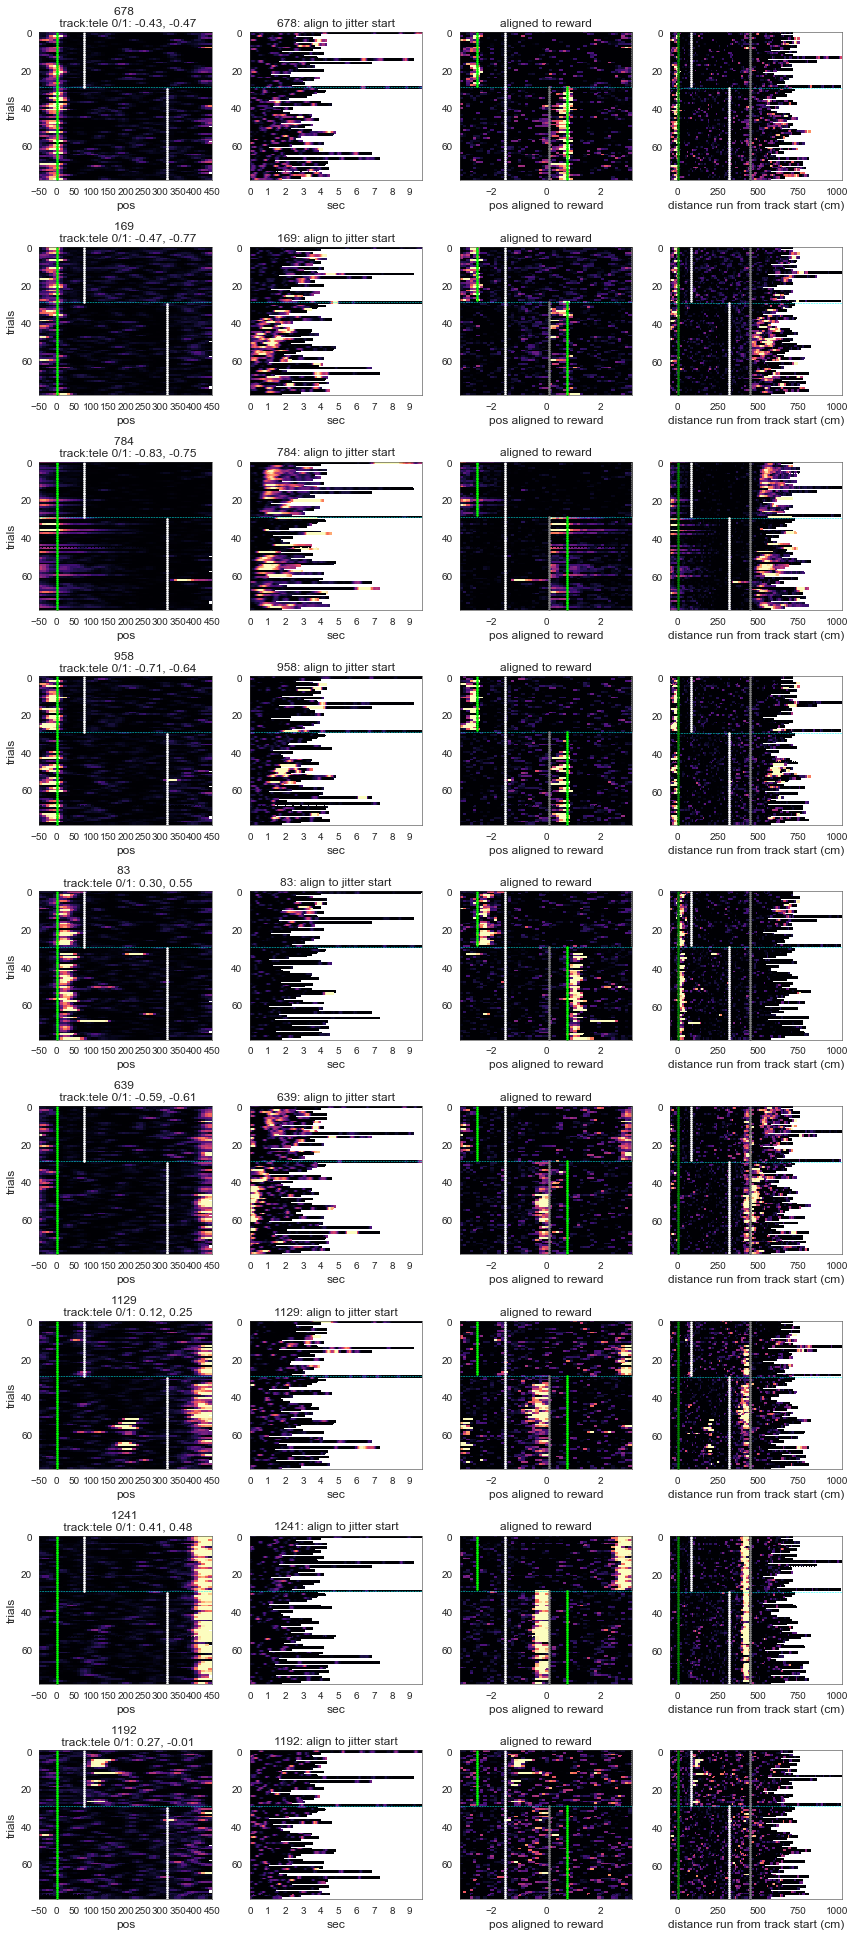

In [32]:
## Plot some example cells, including jitter
## Use pcolormesh to preserve the nan bins

teleport_cells = np.unique(df_fr['cell'][(df_fr['fr_ratio']< -0.3)].values) # cells with high teleport specificity
cells_to_plot= [678, 169, 784, 958, 83, 639, 1129, 1241, 1192]
fig, ax = plt.subplots(len(cells_to_plot),4,figsize=(12,3*len(cells_to_plot)))
reward_zone, rz_label = behav.get_reward_zones(sess)

cmap = 'magma' 

for c_i,c in enumerate(cells_to_plot):
    

    ## spatial
    ax[c_i,0].pcolormesh(bin_centers,
                         np.arange(0,tt_mat.shape[0]),
                         ut.nansmooth(tt_mat[:,:,c],1, axis=1, return_nans=True),
                         vmin=0, vmax=12,shading='auto', cmap=cmap)
    
    ax[c_i,0].plot(np.zeros(tt_mat.shape[0]),
                      np.arange(tt_mat.shape[0]), '.', markersize=3, color=(0,1,0,1))
    ax[c_i,0].plot(reward_zone[:-1,0],
                      np.arange(tt_mat.shape[0]), 'w.', markersize=3)
    ax[c_i,0].invert_yaxis()
        
    
    ax[c_i,0].set_title("%d \n track:tele 0/1: %.2f, %.2f" % (c, 
                                                          mean_ratio['set 0'][np.where(pop_to_use == c)[0]],
                                                          mean_ratio['set 1'][np.where(pop_to_use == c)[0]]
                                                        ), 
                       )
    
    ## time in jitter, aligned to start
    ax[c_i,1].pcolormesh(np.arange(0,align_start[:,:,c].shape[1])*frametime,
                         np.arange(0,align_start[:,:,c].shape[0]),
                         ut.nansmooth(align_start[:,:,c],1, axis=1, return_nans=True),
                         vmin=0, vmax=12, shading='auto', cmap=cmap)
    ax[c_i,1].xaxis.set_major_locator(MaxNLocator(integer= True, min_n_ticks= 2))
    ax[c_i,1].invert_yaxis()
    
    ## circularly aligned, spatial
    ax[c_i,2].pcolormesh(out['circ_tm'][-1],
                         np.arange(0,out['circ_tm'][0].shape[0]),
                        out['circ_tm'][0][:,:,c],
                         vmin=0, vmax=12,shading='auto', cmap=cmap)

    ax[c_i,2].invert_yaxis()
    ax[c_i,2].set_xlabel('pos aligned to reward')
    ax[c_i,2].plot(out['aligned_locs'][:,0],np.arange(out['circ_tm'][0].shape[0]), 'w.', markersize=3)
    ax[c_i,2].plot(out['trackstarts'],np.arange(out['circ_tm'][0].shape[0]), '.',color=(0,1,0,1), markersize=3)
    ax[c_i,2].plot(out['teleports'],np.arange(out['circ_tm'][0].shape[0]), '.', color='grey', markersize=3)
    
    ## with run in teleport binned by distance
    ax[c_i,3].pcolormesh(max_dist_bins,
                         np.arange(dist['trial_mat_neural'][:,:,c].shape[0]),
                         dist['trial_mat_neural'][:,:,c],
                        vmin=0, vmax=12,shading='auto', cmap=cmap)
    ax[c_i,3].plot(reward_zone[dist['trials'],0],
                      np.arange(dist['trial_mat_neural'].shape[0]), 'w.', markersize=3)
    ax[c_i,3].plot(np.ones((dist['trial_mat_neural'].shape[0],))*450,
                      np.arange(dist['trial_mat_neural'].shape[0]), '.', color='grey', markersize=3)
    ax[c_i,3].plot(np.zeros((dist['trial_mat_neural'].shape[0],)),
                      np.arange(dist['trial_mat_neural'].shape[0]), '.', color='green', markersize=3)
    ax[c_i,3].invert_yaxis()
    ax[c_i,3].set_xlabel('distance run from track start (cm)')
     
    [ax[c_i,j].hlines(np.where(trial_set0)[0][-1], 
                      ax[c_i,j].get_xlim()[0], 
                     ax[c_i,j].get_xlim()[-1], 
                 linestyle='--',color='cyan', linewidth=0.5) for j in range(ax.shape[1])]
    ax[c_i,1].set_title(("%d: align to jitter start") % c)
    ax[c_i,2].set_title(("aligned to reward"))
    ax[c_i,0].set_ylabel('trials')
    ax[c_i,1].set_xlabel('sec')
    ax[c_i,0].set_xlabel('pos')
    ax[c_i,0].set_xlabel('pos')
    
    ax[c_i,0].set_xticks(np.arange(bin_edges[0],
                                  bin_edges[-1]+50,
                                  50))
    # pt.colorbar(j)
    pt.colorbar(h)

save_figures = False

if sort_by_jitter_len:
    sort_tag = '_sortByJitter'
else:
    sort_tag = ''

if len(cells_to_plot)<=5:
    cell_str = '-'.join([str(cc) for cc in cells_to_plot])
else:
    cell_str = f"{cells_to_plot[0]}--{cells_to_plot[-1]}"
figfile = os.path.join(fig_dir,"%s_expday%d_pCP_wTeleportJitter_DistRun_%s_cells%s_%s%s.pdf" % (
    an,day,ct, cell_str, cmap, sort_tag
))
print(figfile)
if save_figures:
    print("saving...")
    #fig = plt.gcf()
    fig.savefig(figfile)

## Compute important multiDayData elements including teleport in a new "miniDayData"

In [ ]:
## initialize multidaydata more simply and make a mini one with almost nothing in it
miniDayData = {}
for day in exp_days:
    multi_anim_sess = ut.quick_load_multi_anim_sess(day, anim_list = tele_anim_list)
    
    # remove empty animals
    empty = [len(multi_anim_sess[an])==0 for an in tele_anim_list]
    anim_list_this_day = tele_anim_list[~np.asarray(empty)]
    miniDayData[day] = dd.dayData(anim_list_this_day,
                               multi_anim_sess,

                               exp_day=day,
                               experiment='MetaLearn',
                                # timeseries to use
                               file_ts_key='events',  # 'dff' or 'events' - to calculate place cells
                               ts_key='dff',  # to use for analysis, reward cell fractions,
    #                                            # finding place cell peaks
                               force_two_sets=True,  # of trials
                             use_speed_thr=True,
                             speed_thr=2,
                             exclude_int=True,
                             int_thresh=0.5,
                             int_method='speed',
                             exclude_end_cells=False,
                                               exclude_reward_cells=False,
                                               exclude_not_reward_cells=False,
                                               exclude_track_cells=False,
                             reward_dist_exclusive=50,
                             reward_dist_inclusive=50,
                             stability_threshold=None,

                              )

In [ ]:
# find RR cells with the data that includes the teleport
use_speed_thr=True
lin_bin_size = 10
xcorr_thr=5
speed_thr = 2
output_shuffle = False
trial_subsets = True
nperms = 100
p_thr = 0.05  # p value threshold
stability_thr = None
shuffle_method = 'population' # 'individual' or 'population'
min_missing_trials = 10

include_ans = multiDayData[exp_days[0]
                           ].circ_rel_stats_across_an['include_ans']
include_ans = include_ans[np.isin(include_ans, tele_anim_list)].tolist()

for day in exp_days:

    multi_anim_sess = ut.quick_load_multi_anim_sess(day, anim_list = tele_anim_list )
    tmp_anim_list = []

    for an in include_ans:
        
        if len(multi_anim_sess[an])>0:
            tmp_anim_list.append(an)
            # find distance traveled after teleport before start of next trial
            dist = calc_teleport_run_distance_next_trial(multi_anim_sess[an]['sess'], smooth=False, 
                                                         ts_key='events', norm_ts=False, speed_thr=0,
                                                        trial_end = 'tunnel')
            # find first column where there are ANY nans
            in_teleport = np.where(dist['trial_mat_pos']==455)[1]
            find_first_nancol = np.any(np.isnan(dist['trial_mat_pos']),axis=0)
            if np.any(find_first_nancol):
                first_nancol = np.where(find_first_nancol)[0][0]
                # cells_set_1 = cells_set_1[:,:nancol]
                print(first_nancol)

            # find last column with fewer than 10 nans
            last_good_col = np.where(
                np.sum(np.isnan(dist['trial_mat_pos']), axis=0) < min_missing_trials
            )[0][-1]

            # do a real place cell calculation and shuffle using the distance run vector (posxtime) 
            # as "position", up until the post-teleport bins that we identified with extended_trial_mat
            distxtime = np.copy(dist['dist_timeseries'])
            pos = np.copy(multi_anim_sess[an]['sess'].vr_data['pos'].values)
            ## accept bins in teleport with 0 missing trials
            # max_pos = np.min([dist['bin_edges'][t].max() for t in dist['bin_edges'].keys()]) #dist['trial_mat_pos'][:,:first_nancol-1].ravel().max() + lin_bin_size/2
            ## accept bins in teleport with no fewer than 10 missing trials
            max_pos = np.nanmax(dist['trial_mat_pos'][:,last_good_col]) + lin_bin_size/2
            min_pos = np.nanmin(np.concatenate([dist['bin_edges'][i] for i in dist['bin_edges'].keys()]))


            # -- Calc place cell boolean masks --
            # mask: boolean mask of whether cell is a place cell
            # SI: spatial information
            # p value from permutation
            speed = np.copy(multi_anim_sess[an]['sess'].vr_data['speed']._values)

            pc_out = spatial.calc_place_cells(multi_anim_sess[an]['sess'],
                                         ts_key='events',
                                         trial_subsets=trial_subsets,
                                         include_teleports=True,
                                         nperms=nperms,
                                         output_shuffle=output_shuffle,
                                         pos = distxtime,
                                         speed=speed,
                                         speed_thr=speed_thr,
                                         p_thr=p_thr,
                                         stability_thr=stability_thr,
                                         shuffle_method=shuffle_method,
                                         bin_size=10,
                                         min_pos=min_pos,
                                         max_pos=max_pos,
                                         )

            if trial_subsets:
                #masks = np.multiply(pc_out['masks0'],pc_out['masks1'])
                masks = np.logical_or(pc_out['masks0'], pc_out['masks1'])
            else:
                masks = pc_out['masks0']

            multi_anim_sess[an]['pc masks set0'] = pc_out['masks0']
            multi_anim_sess[an]['pc masks set1'] = pc_out['masks1']

            ## compute new trial matrix with teleports included
            ## if using inds from dist, these will be slightly different from those used for the place cell 
            ## calc (the tunnel will be shifted up one trial)
            tstart_inds = np.asarray(dist['trial_start_inds']) #multi_anim_sess[an]['sess'].trial_start_inds[:-2] 
            tstop_inds = np.asarray(dist['trial_end_inds']) #multi_anim_sess[an]['sess'].trial_start_inds[1:][:-1]

            trial_mat_w_tele = TwoPUtils.spatial_analyses.trial_matrix(multi_anim_sess[an]['sess'].timeseries['events'].T,
                                                                                                 distxtime, 
                                                                                                 tstart_inds, 
                                                                                                 tstop_inds, 
                                                                                                 bin_size=10,
                                                                                                 min_pos = min_pos,
                                                                                                 max_pos=max_pos, 
                                                                                                 speed=speed, 
                                                                                                 speed_thr=2, 
                                                                                                )

            multi_anim_sess[an]['sess'].add_trial_matrix_from_array('tele_events', trial_mat_w_tele)

            trial_mat_w_tele_dff = TwoPUtils.spatial_analyses.trial_matrix(multi_anim_sess[an]['sess'].timeseries['dff'].T,
                                                                                                 distxtime, 
                                                                                                 tstart_inds, 
                                                                                                 tstop_inds, 
                                                                                                 bin_size=10,
                                                                                                 min_pos = min_pos,
                                                                                                 max_pos=max_pos, 
                                                                                                 speed=speed, 
                                                                                                 speed_thr=2, 
                                                                                                )

            multi_anim_sess[an]['sess'].add_trial_matrix_from_array('tele_dff', trial_mat_w_tele_dff)

            ## Now compute circ relative peaks and reward relative cells

            rzone0_start = miniDayData[day].rzone_pos[an]['set 0'][0]
            rzone1_start = miniDayData[day].rzone_pos[an]['set 1'][0]

            distxtime_clipped = np.copy(distxtime)
            distxtime_clipped[distxtime>max_pos] = np.nan
            trial_dict_clipped = {'trial_set0': miniDayData[day].trial_dict[an]['trial_set0'][dist['trials']],
                                   'trial_set1': miniDayData[day].trial_dict[an]['trial_set1'][dist['trials']]
                                 }
            
            multi_anim_sess[an]['trial dict']['trial_set0'] = trial_dict_clipped['trial_set0']
            multi_anim_sess[an]['trial dict']['trial_set1'] = trial_dict_clipped['trial_set1']
            miniDayData[day].trial_dict[an] = trial_dict_clipped
            multi_anim_sess[an]['rzone'] = multi_anim_sess[an]['rzone'][dist['trials']]
            multi_anim_sess[an]['rz label'] = multi_anim_sess[an]['rz label'][dist['trials']]

            circ_bins = ((max_pos-min_pos)/lin_bin_size)
            if (circ_bins % 1) != 0:
                raise NotImplementedError("Number of bins for circ trial matrix is not an integer -- check max position")

            circ_bin_size = np.mean(np.ediff1d(np.linspace(-np.pi, np.pi, int(circ_bins))))
            circ_rzone0 = spatial.pos_cm_to_rad(
                rzone0_start, max_pos, min_pos)
            circ_rzone1 = spatial.pos_cm_to_rad(
                rzone1_start, max_pos, min_pos)

            rdist_to_rad_exc = circ.phase_diff(
                        spatial.pos_cm_to_rad(
                            50, max_pos, min_pos=min_pos),
                spatial.pos_cm_to_rad(0, max_pos, min_pos=min_pos)
            )
            rdist_to_rad_inc = circ.phase_diff(
                spatial.pos_cm_to_rad(
                    50, max_pos, min_pos=min_pos),
                spatial.pos_cm_to_rad(0, max_pos, min_pos=min_pos)
            )

            miniDayData[day].circ_rel_stats_across_an = {'include_ans': include_ans,
                                                     'rdist_to_rad_inc': rdist_to_rad_inc,
                                                     'rdist_to_rad_exc': rdist_to_rad_exc,
                                                         'min_pos': min_pos,
                                                         'max_pos': max_pos,
                                                        }

            bin_edges = np.arange(-np.pi, np.pi+circ_bin_size, circ_bin_size)
            bin_centers = bin_edges[:-1]+circ_bin_size/2

            # circular position but NOT aligned to reward zone
            circ_pos = spatial.pos_cm_to_rad(
                distxtime, max_pos, min_pos=min_pos)

            activity_ts = np.copy(
                multi_anim_sess[an]['sess'].timeseries['dff'].T)

            if use_speed_thr:
                speed = np.copy(multi_anim_sess[an]
                                ['sess'].vr_data['speed'].values)
            else:
                speed = None


            # Make spatially-binned trial matrix for neural activity in circular coordinates
            circ_tm = TwoPUtils.spatial_analyses.trial_matrix(activity_ts,
                                                              circ_pos,
                                                              tstart_inds,
                                                              tstop_inds,
                                                              bin_size=circ_bin_size,
                                                              min_pos=-np.pi,
                                                              max_pos=np.pi,
                                                              speed_thr=2,
                                                              speed=speed
                                                              )

            # keep_masks = np.copy(miniDayData[day].overall_place_cell_masks[an])
            ## Use the new place cell masks that include the teleport
            keep_masks = masks
            miniDayData[day].keep_masks[an] = keep_masks


            use_tm = circ_tm[0]
            # if kwargs['smooth']:
            #     use_tm = ut.nansmooth(use_tm, kwargs['sigma'], axis=1)

            # keep a copy of the circular trial matrix with all the cells
            miniDayData[day].circ_trial_matrix[an] = circ_tm


            for t in ['0', '1']:
                if t == '0':
                    tmp_circ_pos = circ.wrap(circ_pos - circ_rzone0)

                else:
                    tmp_circ_pos = circ.wrap(circ_pos - circ_rzone1)


                miniDayData[day].circ_map[an].update(
                    {'set ' + t: use_tm[trial_dict_clipped['trial_set'+t],:,:]})

            circ_peaks_0 = spatial.peak(np.nanmean(
                miniDayData[day].circ_map[an]['set 0'], axis=0),
                circ_tm[-1], axis=0)
            circ_peaks_1 = spatial.peak(np.nanmean(
                miniDayData[day].circ_map[an]['set 1'], axis=0),
                circ_tm[-1], axis=0)



            circ_peaks_0 = circ_peaks_0[keep_masks]
            circ_peaks_1 = circ_peaks_1[keep_masks]

            rel_peaks0 = circ.wrap(circ_peaks_0 - circ_rzone0)
            rel_peaks1 = circ.wrap(circ_peaks_1 - circ_rzone1)

       
            miniDayData[day].rel_peaks[an]['set 0'] = rel_peaks0
            miniDayData[day].rel_peaks[an]['set 1'] = rel_peaks1
           
            # "distance along unity": circular mean of pre-switch and post-switch relative distance from reward
            kept_cells, _ = dd._mean_rel_dist(
                rel_peaks0, rel_peaks1, rdist_to_rad_inc)

            # store inds that are within dist_inc of the unity line
            # miniDayData[day].dist_along_unity_inds[an] = kept_cells  # boolean mask
            miniDayData[day].reward_rel_cell_ids[an] = np.where(
                keep_masks)[0][kept_cells]

            # Now further filter those to find reliable reward relative cells
            # Xcorr shuffle to check reward rel cells - perform xcorr for all cells
            _, xc_peaks_above_shuf = dd.calc_field_xcorr(circ_tm, trial_dict_clipped,
                                                      rzone0_start, rzone1_start,
                                                      circ_rzone0, circ_rzone1,
                                                      n_perms=500, circ_shift=True,
                                                      cell_subset=None)

            # keep cells whose xc peak above the shuffle is <= xcorr_thr (5 bins) away from zero
            # currently assuming these are 10-cm bins
            miniDayData[day].xcorr_above_shuf[an] = xc_peaks_above_shuf
            reward_rel_above_shuf_bool = np.abs(xc_peaks_above_shuf)[
                miniDayData[day].reward_rel_cell_ids[an]] <= xcorr_thr
            miniDayData[day].reward_rel_cell_ids[an] = miniDayData[day].reward_rel_cell_ids[an][
                reward_rel_above_shuf_bool]

            # sub in the matrix with the teleport data
            miniDayData[day].activity_matrix[an] = trial_mat_w_tele_dff

    miniDayData[day].anim_list = tmp_anim_list
    ## Add cell class masks
    miniDayData[day].get_cell_classes(multi_anim_sess, inc_dist=50,
                                      ts_key='tele_events')

In [ ]:
# Save minidaydata
from datetime import datetime
pkl_name = "%s_expdays%s_miniDayData_%s_unsmoothed_excInt0.5_inc50_useSpeed_incTeleport.pickle" % (
    ut.make_anim_tag(tele_anim_list),
    ut.make_day_tag(exp_days),
    load_ts_key,
)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multiDayData', pkl_name)
save_pkl = open(pkl_path, "wb")
pickle.dump(miniDayData, save_pkl)
# Close the pickle
save_pkl.close()

In [34]:
# Load pickled miniDayData
load_ts_key = 'dff'
pkl_name = "%s_expdays%s_miniDayData_%s_unsmoothed_excInt0.5_inc50_useSpeed_incTeleport.pickle" % (
    ut.make_anim_tag(tele_anim_list),
    ut.make_day_tag(exp_days),
    load_ts_key,
)
pkl_path = os.path.join(
    path_dict['preprocessed_root'], 'multiDayData', pkl_name)
miniDayData = pickle.load(open(pkl_path, "rb"))

In [ ]:
miniDayData.keys()

## Plot sorted cell sequences including activity in the teleport period

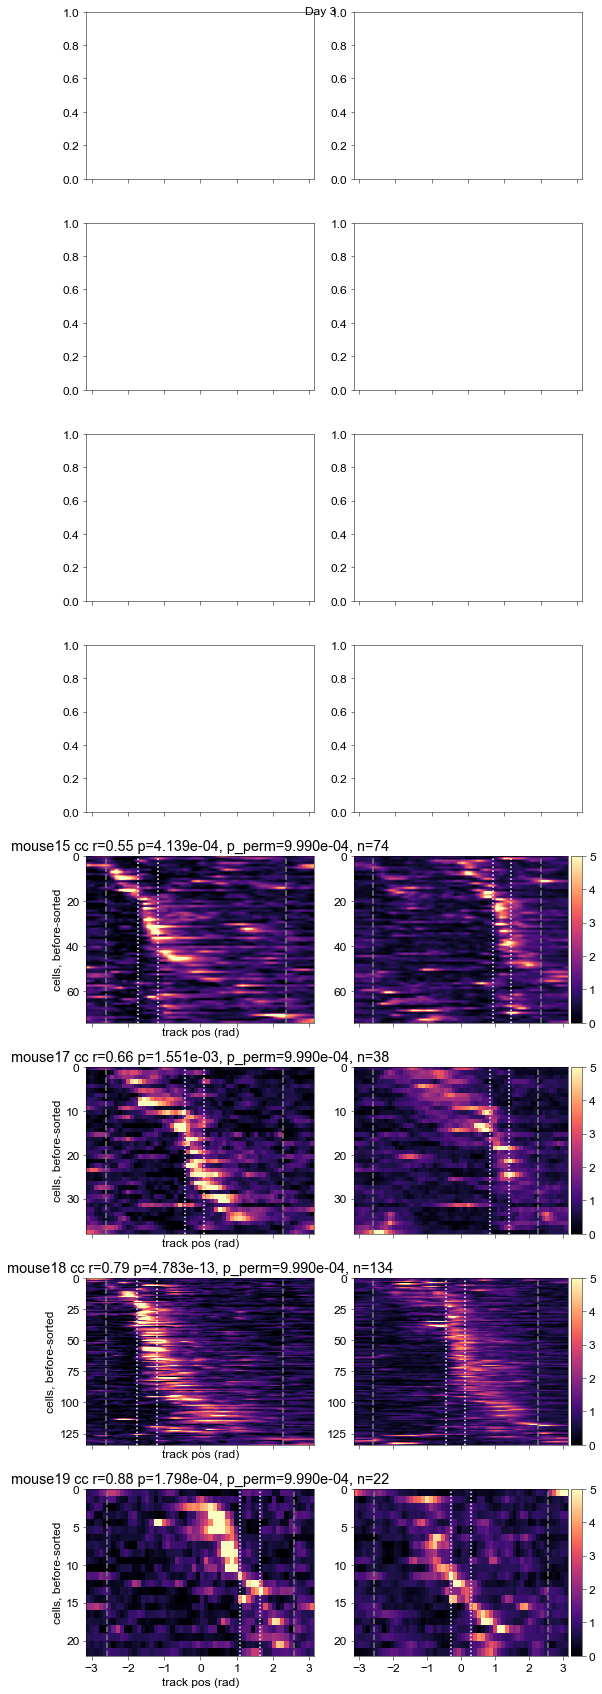

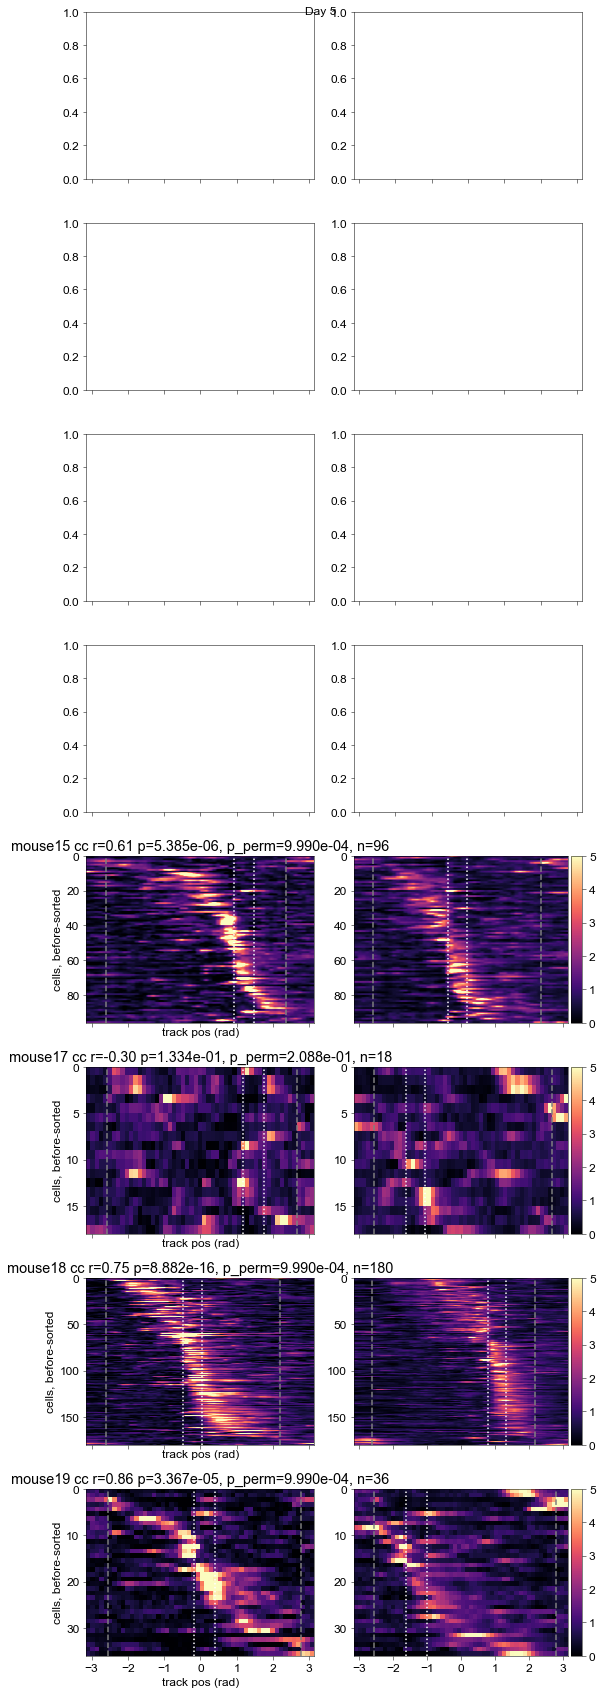

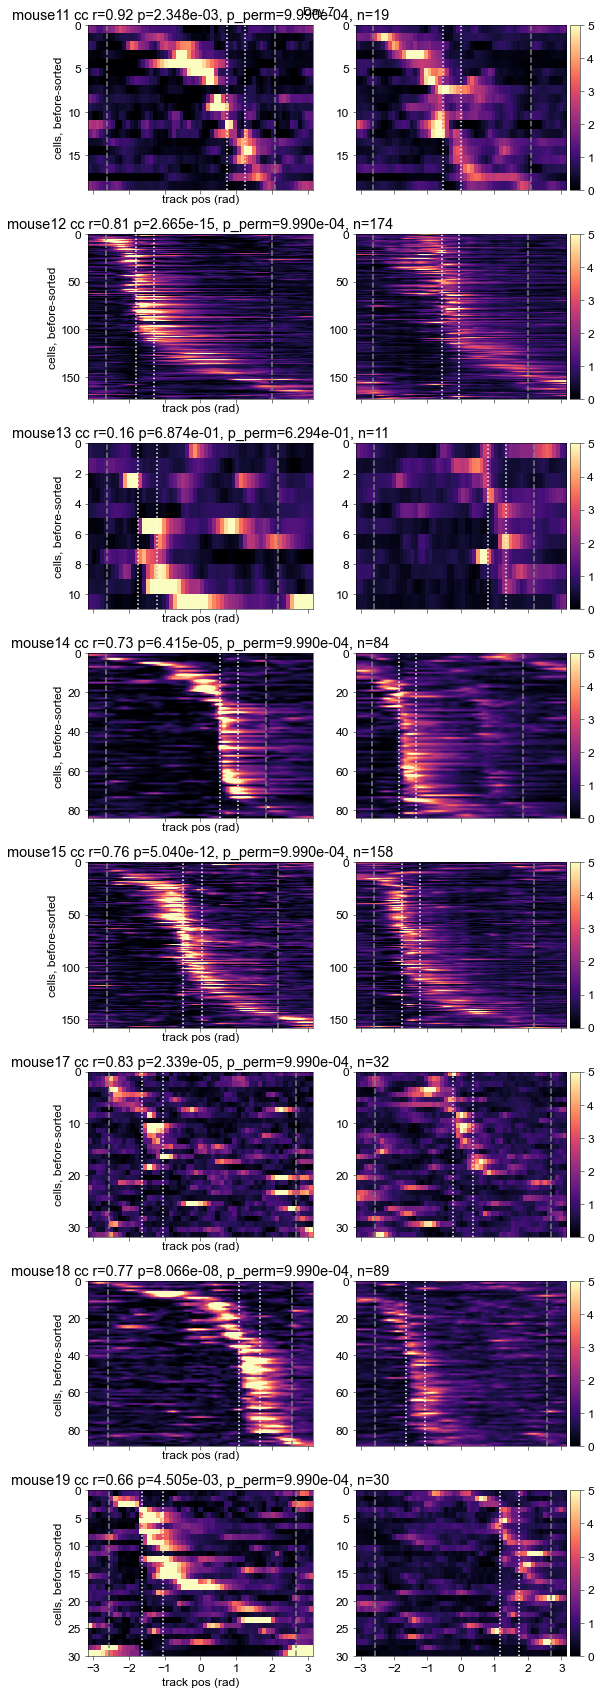

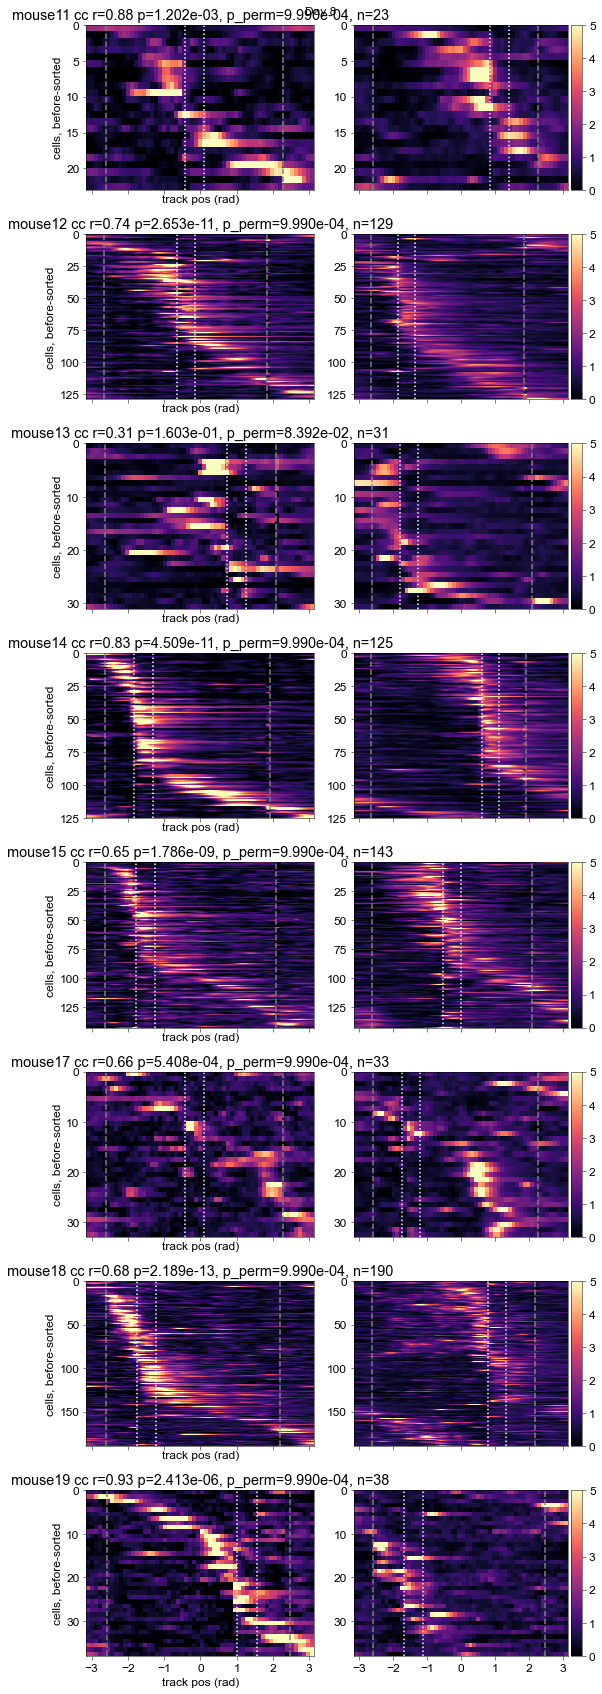

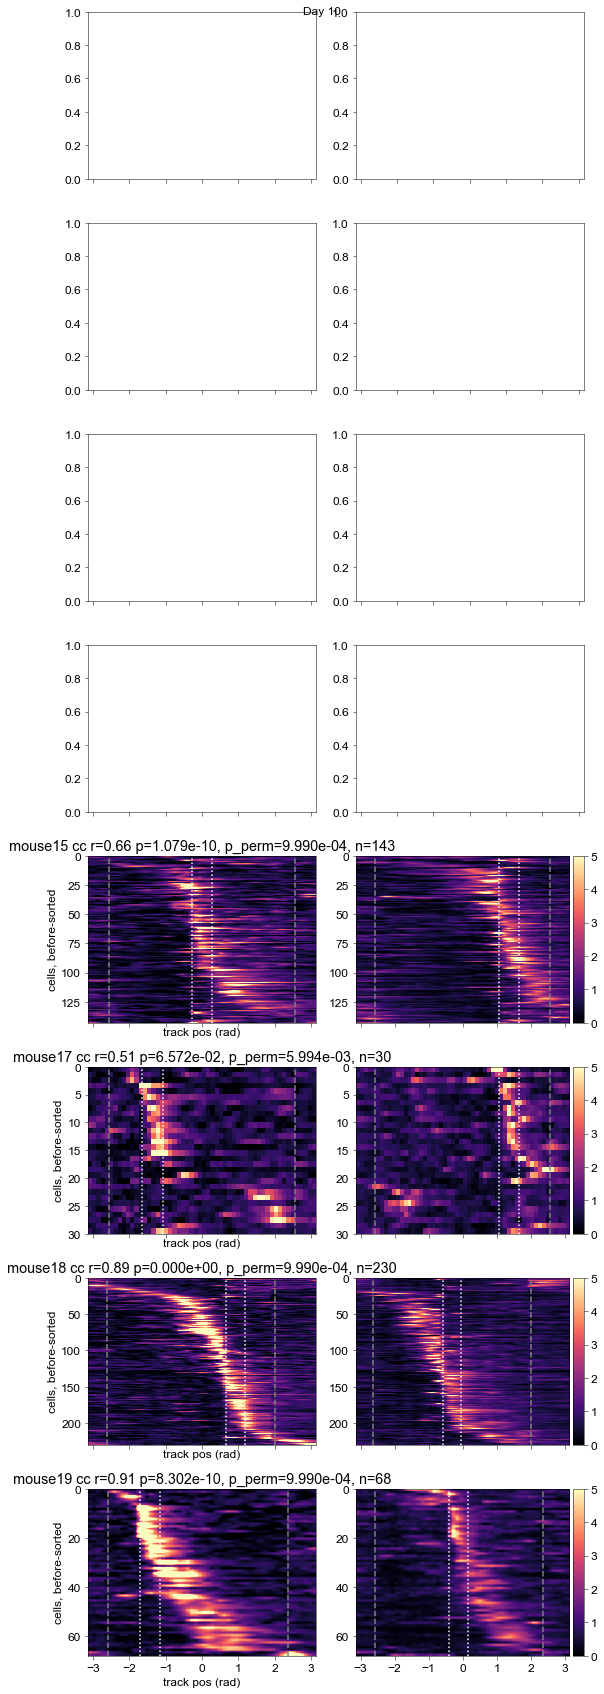

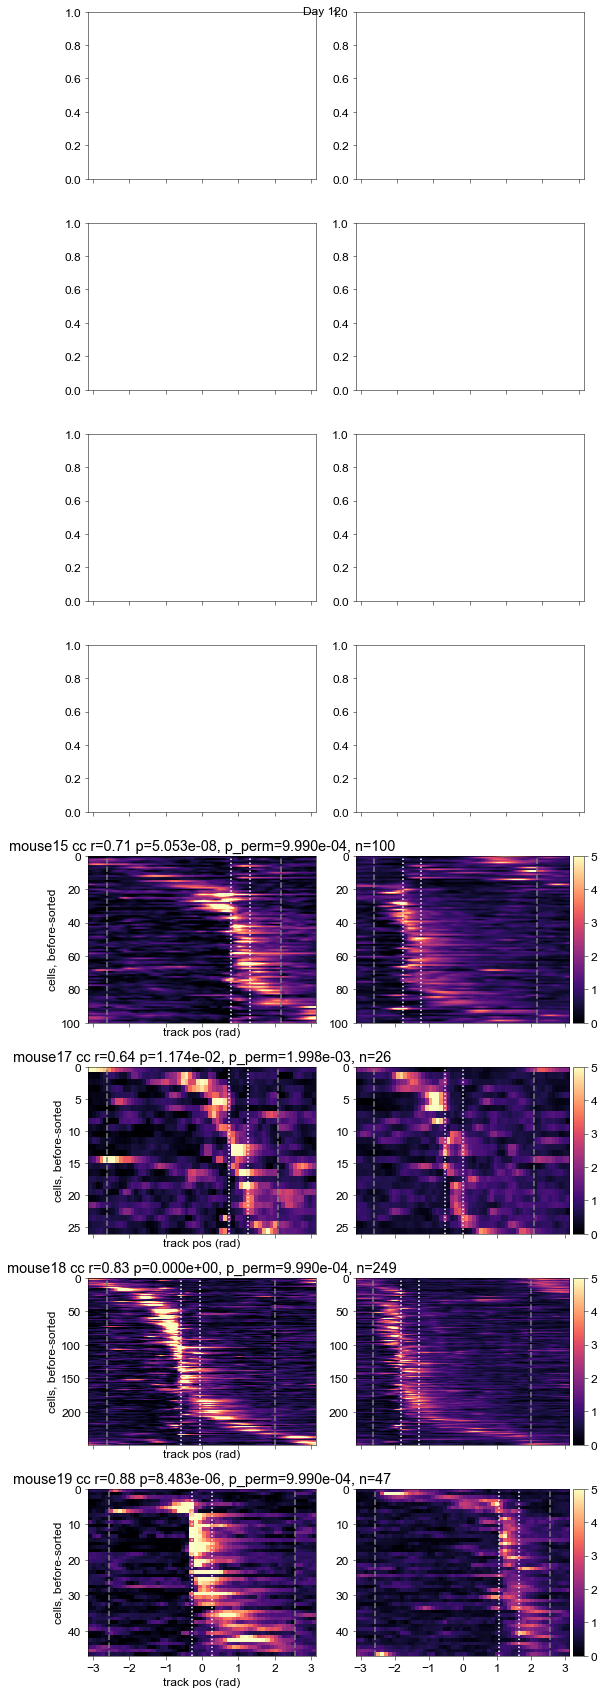

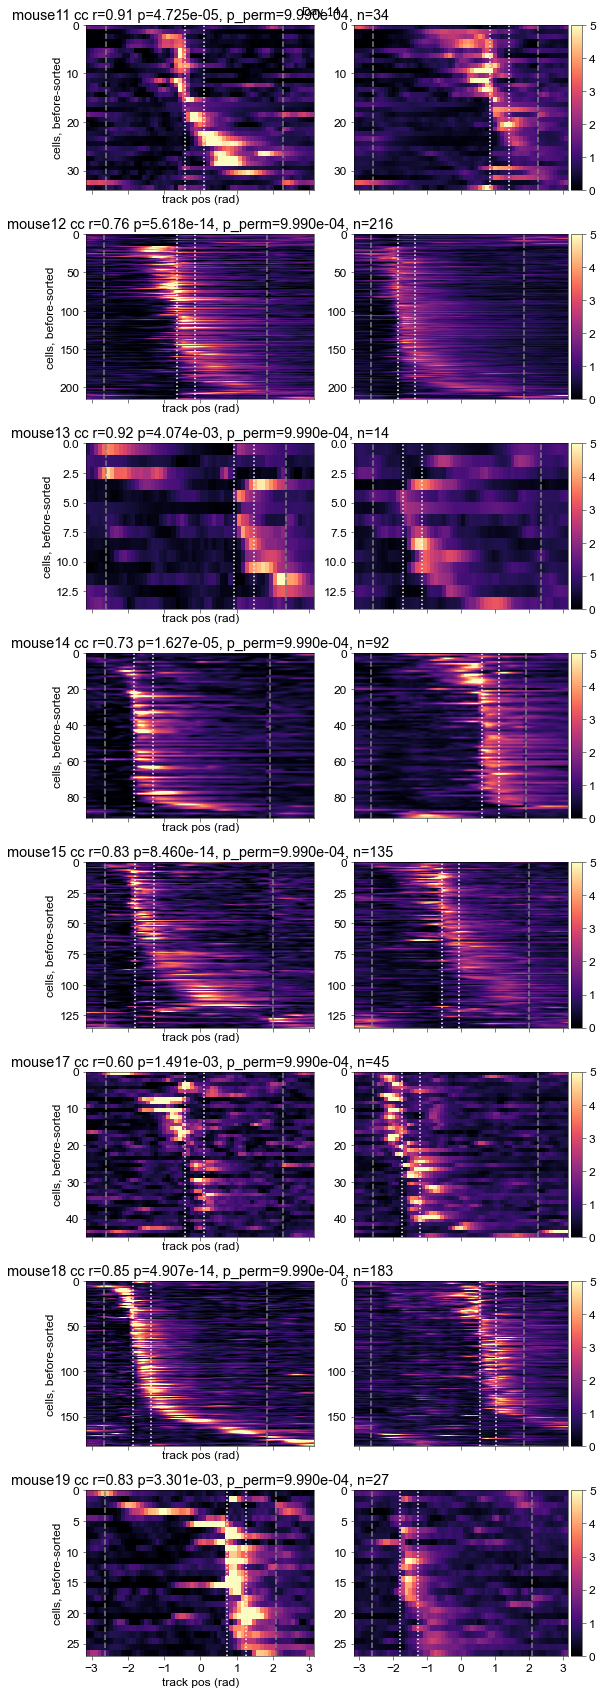

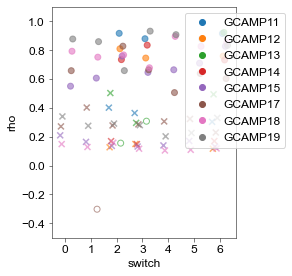

In [41]:
celltype='rr'

include_ans = multiDayData[exp_days[0]
                           ].circ_rel_stats_across_an['include_ans']
include_ans = include_ans[np.isin(include_ans, tele_anim_list)].tolist()
seq, _, fig, fig_q = placeCellPlot.plot_sequences(miniDayData,
                                 celltype=celltype,
                                 daylist=exp_days,
                                 smooth=False,
                                 use_peaks=True,
                                 use_circ_mean=False,
                                 plot=True,
                                 save_figures=False,
                                 fig_dir=fig_dir,
                                 fig_tag='incTeleport',
                                 sort_by_set1=False,
                                 last_10_trials=False,
                                 plot_teleport=True,
                                 vmax=5,
                                 vbin=1,
                                 vmin=0,
                                 include_ans=include_ans,
                                 p_thr=0.05,)

## Density of sequences: both RR and TR cells

In [43]:
for day in exp_days:
    for an in miniDayData[day].anim_list:
        miniDayData[day].cell_class[an]['masks']['track'] = miniDayData[day].cell_class[an]['masks'].pop('stable')
        miniDayData[day].cell_class[an]['fractions_placeor']['track'] = miniDayData[day].cell_class[an]['fractions_placeor'].pop('stable')
        miniDayData[day].cell_class[an]['fractions_total']['track'] = miniDayData[day].cell_class[an]['fractions_total'].pop('stable')

In [77]:
# Shape of sequences for each animal after the switch

palette = 'tab10'
seaborn_palette = sns.color_palette(
    palette, len(include_ans))  # , as_cmap=True)
rgb_tuples = [sns.color_palette(seaborn_palette)[i]
              for i in range(len(seaborn_palette))]
cmap = np.asarray(rgb_tuples)

plot = False
if plot:
    fig2, ax2 = plt.subplots(len(exp_days), 2, figsize=(8, len(exp_days)*4))

alphas = np.linspace(0.2, 1, len(exp_days))

mean_seq_pos = {}

cols = ['mouse', 'day', 'switch', 'sess_id', 'switch_dir','tunnel','start', 'middle', 'end',
        'jitter', 
]
TR_shape_df = pd.DataFrame(data=np.zeros((len(exp_days)*len(include_ans),len(cols))), columns=cols)
TR_shape_df['mouse'] = np.tile(include_ans, (len(exp_days),1)).ravel()
TR_shape_df['day'] = np.repeat(exp_days, len(include_ans))
TR_shape_df['switch'] = np.repeat(np.arange(len(exp_days)), len(include_ans)).astype(float)
TR_shape_df['sess_id'] = np.zeros((len(np.repeat(exp_days, len(include_ans))),))

mean_seq_pos = {'RR': {},
                'TR': {}
               }

# max pos of all days and animals:
# chance is going to be tricky because we're undersampling the bins at the end
# decided to omit the estimated uniform lines because of this
maxmax_pos = [np.max([miniDayData[day].activity_matrix[an][-2][-1] for an in miniDayData[day].anim_list])  
              for day in exp_days]
maxmax_pos = np.max(maxmax_pos)
min_pos = -50

# animals that have imaging in the teleport on all days
tele_an_all_days = ['GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19']

aligned_tele_circ_pos = np.array([])
aligned_start_circ_pos = np.array([])
rz_tally = np.array([])


for d_i, day in enumerate(exp_days):

    mean_seq_pos['RR'][day] = {}
    mean_seq_pos['TR'][day] = {}    

    for an_i, an in enumerate(include_ans):
          
        if an in miniDayData[day].anim_list:
            _circpos = miniDayData[day].circ_trial_matrix[an][-1]
            
            lin_pos_bin_centers = miniDayData[day].activity_matrix[an][-1]
            max_pos_this_sess = miniDayData[day].activity_matrix[an][-2][-1]
            # circular coordinate of the start and end of the track, now that we've included teleport
            tele_circ = spatial.pos_cm_to_rad(450, maxmax_pos, min_pos)
            start_circ = spatial.pos_cm_to_rad(0, maxmax_pos, min_pos)

            _, cell_inds = dd.get_cell_class_n(miniDayData, day, an, verbose=False)

            # get linear peaks
            peaks_0 = spatial.peak(np.nanmean(
                miniDayData[day].activity_matrix[an][0][miniDayData[day].trial_dict[an]['trial_set0'], :, :], 
                axis=0),
                miniDayData[day].activity_matrix[an][-1], axis=0)
            
            peaks_1 = spatial.peak(np.nanmean(
                miniDayData[day].activity_matrix[an][0][miniDayData[day].trial_dict[an]['trial_set1'], :, :], 
                axis=0),
                miniDayData[day].activity_matrix[an][-1], axis=0)
            
            
            rr_peaks_0 = peaks_0[miniDayData[day].reward_rel_cell_ids[an]]
            rr_peaks_1 = peaks_1[miniDayData[day].reward_rel_cell_ids[an]]

            tr_peaks_0 = peaks_0[cell_inds['track']]
            tr_peaks_1 = peaks_1[cell_inds['track']]
            
            # convert to radians from the start of the track
            rr_circ_peaks_0 = spatial.pos_cm_to_rad(rr_peaks_0, maxmax_pos, min_pos)
            rr_circ_peaks_1 = spatial.pos_cm_to_rad(rr_peaks_1, maxmax_pos, min_pos)
            
            tr_circ_peaks_0 = spatial.pos_cm_to_rad(tr_peaks_0, maxmax_pos, min_pos)
            tr_circ_peaks_1 = spatial.pos_cm_to_rad(tr_peaks_1, maxmax_pos, min_pos)
            
            rpos1 = spatial.pos_cm_to_rad(
                    miniDayData[day].rzone_pos[an]['set 1'][0], maxmax_pos, min_pos)
            
            # for RR cells, align to reward
            mean_seq_pos['RR'][day][an] = circ.wrap(rr_circ_peaks_1 - rpos1)
            
            aligned_tele_circ_pos = np.append(aligned_tele_circ_pos, circ.wrap(tele_circ - rpos1))
            aligned_start_circ_pos = np.append(aligned_start_circ_pos, circ.wrap(start_circ - rpos1))
            # keep track of which reward zones we have
            rz_tally = np.append(rz_tally, miniDayData[day].rzone_label[an]['set 1'][0])
            
            # for TR cells, just take the post-switch peaks
            mean_seq_pos['TR'][day][an] = tr_circ_peaks_1

            if np.any(~np.isnan(tr_peaks_1)):

                this_df_idx = ((TR_shape_df['mouse']==an) & (TR_shape_df['day']==day))
                TR_shape_df.loc[this_df_idx, 'sess_id'] = an + ('_%d' % day)

                # get density: fraction of TR cells over cm of segment
                TR_shape_df.loc[this_df_idx, 'tunnel'] = (
                    (((tr_peaks_1>-50) & (tr_peaks_1<0)).sum() / len(tr_peaks_1)) / 50)
                
                TR_shape_df.loc[this_df_idx, 'start'] = (
                    (((tr_peaks_1>0) & (tr_peaks_1<=50)).sum() / len(tr_peaks_1)) / 50)
                TR_shape_df.loc[this_df_idx, 'middle'] = (
                    (((tr_peaks_1>50) & (tr_peaks_1<400)).sum() / len(tr_peaks_1)) / 350)
                
                TR_shape_df.loc[this_df_idx, 'end'] = (
                    (((tr_peaks_1>=400) & (tr_peaks_1<=450)).sum() / len(tr_peaks_1)) / 50)
                TR_shape_df.loc[this_df_idx, 'jitter'] = (
                    (((tr_peaks_1>450)).sum() / len(tr_peaks_1)) / (max_pos_this_sess - 450))

                if miniDayData[day].rzone_pos[an]['set 1'][0] > miniDayData[day].rzone_pos[an]['set 0'][0]:
                    TR_shape_df.loc[this_df_idx,'switch_dir'] = 'forward'
                elif miniDayData[day].rzone_pos[an]['set 1'][0] < miniDayData[day].rzone_pos[an]['set 0'][0]:
                    TR_shape_df.loc[this_df_idx,'switch_dir'] = 'backward'
                else:
                    switch_dir = 'none'

# remove rows with no data
TR_shape_df = TR_shape_df.loc[TR_shape_df['switch_dir']!=0]
TR_shape_df

,mouse,day,switch,sess_id,switch_dir,tunnel,start,middle,end,jitter
4,GCAMP15,3,0.0,GCAMP15_3,forward,0.001849,0.004202,0.001465,0.001765,0.001381
5,GCAMP17,3,0.0,GCAMP17_3,forward,0.001739,0.005000,0.001304,0.002174,0.001223
6,GCAMP18,3,0.0,GCAMP18_3,forward,0.001655,0.004532,0.000791,0.003094,0.003237
7,GCAMP19,3,0.0,GCAMP19_3,backward,0.002824,0.004235,0.000975,0.003059,0.003059
12,GCAMP15,5,1.0,GCAMP15_5,backward,0.002722,0.002959,0.001369,0.002367,0.001691
13,GCAMP17,5,1.0,GCAMP17_5,backward,0.001519,0.002278,0.001664,0.001519,0.003797
14,GCAMP18,5,1.0,GCAMP18_5,forward,0.001507,0.003904,0.000978,0.003151,0.002549
15,GCAMP19,5,1.0,GCAMP19_5,backward,0.002264,0.004717,0.001186,0.003208,0.002516
16,GCAMP11,7,2.0,GCAMP11_7,backward,0.002381,0.002381,0.001497,0.001905,0.001429
17,GCAMP12,7,2.0,GCAMP12_7,forward,0.002186,0.001749,0.001405,0.003060,0.001441


In [80]:
TR_shape_df_melt = pd.melt(TR_shape_df, id_vars=['mouse','day','switch','sess_id','switch_dir'], 
                           value_vars=['start','end','middle','tunnel','jitter'],
                           var_name='segment', 
                           value_name='density')
TR_shape_df_melt

,mouse,day,switch,sess_id,switch_dir,segment,density
0,GCAMP15,3,0.0,GCAMP15_3,forward,start,0.004202
1,GCAMP17,3,0.0,GCAMP17_3,forward,start,0.005000
2,GCAMP18,3,0.0,GCAMP18_3,forward,start,0.004532
3,GCAMP19,3,0.0,GCAMP19_3,backward,start,0.004235
4,GCAMP15,5,1.0,GCAMP15_5,backward,start,0.002959
...,...,...,...,...,...,...,...
195,GCAMP14,14,6.0,GCAMP14_14,forward,jitter,0.001684
196,GCAMP15,14,6.0,GCAMP15_14,forward,jitter,0.002088
197,GCAMP17,14,6.0,GCAMP17_14,backward,jitter,0.001761
198,GCAMP18,14,6.0,GCAMP18_14,forward,jitter,0.001357


### Ext. Fig. 5e

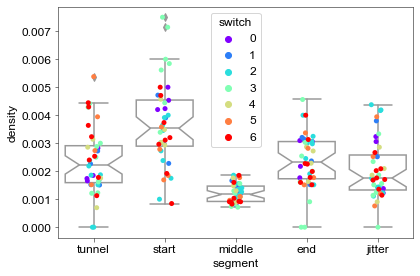

In [81]:
fig, ax = plt.subplots()
sns.boxplot(x='segment', y='density', 
            data=TR_shape_df_melt[TR_shape_df_melt['switch_dir']!=0], 
            order=['tunnel', 'start', 'middle', 'end', 'jitter'],
            color='w',
            notch=True)
sns.stripplot(x='segment', y='density', 
              data=TR_shape_df_melt[TR_shape_df_melt['switch_dir']!=0],
              order=['tunnel', 'start', 'middle', 'end', 'jitter'],
              hue='switch', palette='rainbow')

save_figures=False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_allexpdays_density_TR-peaks-by-segment_incTeleport" % (
        ut.make_anim_tag(include_ans))
           )

In [128]:
ut.write_source_csv(TR_shape_df_melt, "Ext5e")

writing /data/2P/source_data/FigExt5e.csv


In [82]:
import statsmodels.formula.api as smf
import pingouin

In [83]:
# normality check
use_df = TR_shape_df_melt[TR_shape_df_melt['switch_dir']!=0]
for seg in TR_shape_df_melt['segment'].unique():
    print(sp.stats.shapiro(use_df['density'][use_df['segment']==seg]))
    print(sp.stats.normaltest(use_df['density'][use_df['segment']==seg]))

ShapiroResult(statistic=0.9762574434280396, pvalue=0.5531395077705383)
NormaltestResult(statistic=2.375330722912002, pvalue=0.3049323404859274)
ShapiroResult(statistic=0.9655733704566956, pvalue=0.2583851218223572)
NormaltestResult(statistic=1.4743388696443072, pvalue=0.47846633070286027)
ShapiroResult(statistic=0.9492747783660889, pvalue=0.07159756124019623)
NormaltestResult(statistic=4.135762159545163, pvalue=0.12645344278640003)
ShapiroResult(statistic=0.9648279547691345, pvalue=0.24402597546577454)
NormaltestResult(statistic=1.643906951271965, pvalue=0.43957212181103167)
ShapiroResult(statistic=0.9316787123680115, pvalue=0.018277829512953758)
NormaltestResult(statistic=3.464005933328824, pvalue=0.17692967059076112)


In [99]:
# the data are mostly normal, so going ahead with anova
rm_anova_results = pingouin.rm_anova(data=use_df,
                     dv='density',
                     within='segment', # 'switch'], # no effect of switch
                     correction='auto',
                     subject='sess_id',
                    )

# this shows only a significant effect of 
rm_anova_results

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/pingouin/distribution.py:946: RuntimeWarning: divide by zero encountered in double_scalars
  W = np.product(eig) / (eig.sum() / d)**d


,Source,ddof1,ddof2,F,p-unc,np2,eps
0,segment,4,156,24.102797,1.540633e-15,0.381961,0.725132


In [103]:
pingouin.pairwise_ttests(data=use_df,
                         within='segment',
                         subject='sess_id',
                         dv='density',
                         parametric=True,
                         correction='auto',
                         padjust='holm')

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,segment,end,jitter,True,True,1.457049,39.0,two-sided,1.531079e-01,4.593238e-01,holm,0.452,0.294547
1,segment,end,middle,True,True,6.989348,39.0,two-sided,2.216475e-08,1.994828e-07,holm,6.064e+05,1.578948
2,segment,end,start,True,True,-4.029397,39.0,two-sided,2.507879e-04,1.003151e-03,holm,105.618,-1.031009
3,segment,end,tunnel,True,True,0.042058,39.0,two-sided,9.666674e-01,9.666674e-01,holm,0.171,0.011079
4,segment,jitter,middle,True,True,4.634674,39.0,two-sided,3.937104e-05,1.968552e-04,holm,569.638,1.097082
5,segment,jitter,start,True,True,-5.351113,39.0,two-sided,4.114515e-06,3.291612e-05,holm,4569.005,-1.238918
6,segment,jitter,tunnel,True,True,-1.095465,39.0,two-sided,2.800322e-01,5.600644e-01,holm,0.298,-0.252749
7,segment,middle,start,True,True,-9.232620,39.0,two-sided,2.334977e-11,2.334977e-10,holm,4.066e+08,-2.259566
8,segment,middle,tunnel,True,True,-5.106696,39.0,two-sided,8.939049e-06,6.257334e-05,holm,2228.387,-1.283222
9,segment,start,tunnel,True,True,4.798870,39.0,two-sided,2.357629e-05,1.414577e-04,holm,911.867,0.966417


In [104]:
## LMM relative to start segment
# (should be consistent with the ANOVA/t-tests above)
# group is mouse because session id is accounted for by including switch

lmm = smf.mixedlm('density ~ 1 + C(segment, Treatment("start"))*switch', 
                  groups='mouse', 
            re_formula = '~1', data=TR_shape_df_melt).fit()
print("compared to start")
print(lmm.summary())
# print(lmm.params)
print(lmm.pvalues)


compared to start
                          Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            density  
No. Observations:              200                Method:                        REML     
No. Groups:                    8                  Scale:                         0.0000   
Min. group size:               15                 Log-Likelihood:                1011.4700
Max. group size:               35                 Converged:                     Yes      
Mean group size:               25.0                                                       
------------------------------------------------------------------------------------------
                                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                        0.004    0.000 12.786 0.000  0.004  0.005
C(segmen

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/statsmodels/regression/mixed_linear_model.py:2168: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [105]:
# multiple comparison correction for fixed effect pvalues:
# use Benjamini-Yekutieli correction as the densities in each bin are necessarily
# correlated with each other (if one is low, the other is high)
pvals = lmm.pvalues[1:-1].values
_, adj_pvals, _, _ = multipletests(pvals, method='fdr_by')
ser = pd.concat([pd.Series(lmm.fe_params[1:].values), pd.Series(adj_pvals)], axis=1) #, index=lmm_ct.fe_params[1:].index)
ser['fe'] = lmm.fe_params[1:].index
ser

,0,1,fe
0,-0.001647,1.584910e-03,"C(segment, Treatment(""start""))[T.end]"
1,-0.001767,7.202007e-04,"C(segment, Treatment(""start""))[T.jitter]"
2,-0.002908,2.532144e-09,"C(segment, Treatment(""start""))[T.middle]"
3,-0.002578,1.249973e-07,"C(segment, Treatment(""start""))[T.tunnel]"
4,-0.000155,2.873111e-01,switch
5,0.000105,1.000000e+00,"C(segment, Treatment(""start""))[T.end]:switch"
6,0.000049,1.000000e+00,"C(segment, Treatment(""start""))[T.jitter]:switch"
7,0.000139,9.006811e-01,"C(segment, Treatment(""start""))[T.middle]:switch"
8,0.000393,5.547069e-03,"C(segment, Treatment(""start""))[T.tunnel]:switch"


## Density of sequences: RR cells


/home/mari/local_repos/2p_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in true_divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/mari/local_repos/2p_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in true_divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/mari/local_repos/2p_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in true_divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/mari/local_repos/2p_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in true_divide
  return np.nanstd(x_, axis=axis, **kwargs) / np.sqrt(x_.shape[axis] - 1)
/home/mari/local_repos/2p_repos/Sosa_et_al_2024/src/reward_relative/utilities.py:532: RuntimeWarning: invalid value encountered in t

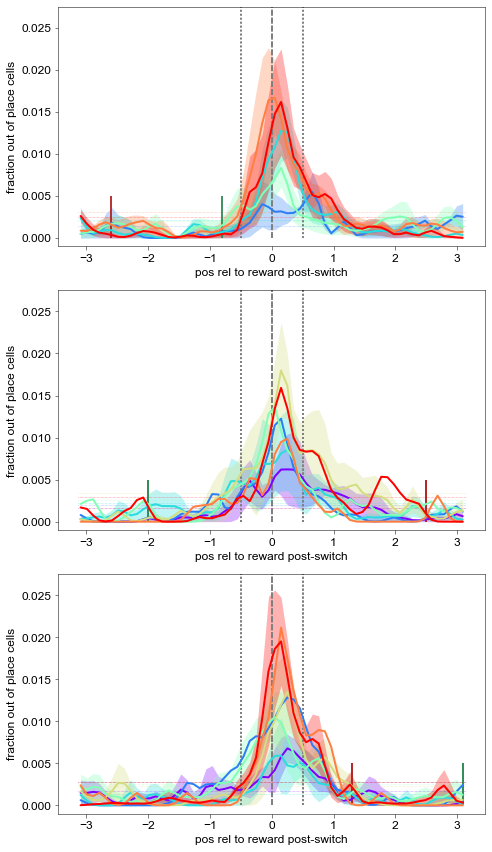

In [109]:
## Plot diff reward zones for RR separately

smooth_histogram = True
daylist= exp_days #[3,5,7,8,10,12,14]
colors = cm.rainbow(np.linspace(0,1,len(daylist)))

lin_bin_size = 10
circ_bins = ((maxmax_pos - min_pos)/lin_bin_size)
bin_size = (2*np.pi)/((maxmax_pos - min_pos)/lin_bin_size)
bin_edges = np.linspace(-np.pi, np.pi, int(circ_bins))
bin_centers = bin_edges[:-1]+bin_size/2


start_tele = np.hstack([aligned_start_circ_pos[:, np.newaxis],aligned_tele_circ_pos[:, np.newaxis]])

ct = 'RR'

fig,ax = plt.subplots(3,1,figsize=(7,12))

    
for d_i,day in enumerate(daylist):
        
    rz_list = [miniDayData[day].rzone_label[an]['set 1'][0] for an in miniDayData[day].anim_list]
    full_an_list = miniDayData[day].anim_list   
    
    for rz_i, rz in enumerate(['A','B','C']): 

        an_to_use = np.array(full_an_list)[np.where(np.array(rz_list)== rz)[0]] 
        
        if len(an_to_use)>0:

            n_all_cells = np.sum([len(miniDayData[day].keep_masks[an]) for an in an_to_use]) # n all cells
            n_place_cells = np.sum([np.sum(miniDayData[day].keep_masks[an]) for an in an_to_use])
            n_seq = [len(mean_seq_pos[ct][day][an]) for an in an_to_use]

            hist_norm_to_all = np.histogram(np.hstack([mean_seq_pos[ct][day][an] for an in an_to_use]
                                                            ),bins=bin_edges)[0] / n_place_cells

            ## Get means across each animals unity hist, normalized to place cells within each animal

            hist_mat = np.hstack([np.expand_dims((np.histogram(mean_seq_pos[ct][day][an], 
                                                           bins=bin_edges)[0] / np.sum(
                miniDayData[day].keep_masks[an])), 
                                   axis=1)
                    for an in an_to_use])
            yax = 'fraction out of place cells'
            normtag = 'ofPlaceCells'

            n_total = n_place_cells

            # chance = mean fraction of pcs within animal comprised by the sequence, 
            # divided by the number of bins
            seq_of_pcs_list = [len(mean_seq_pos[ct][day][an])/np.sum(miniDayData[day].keep_masks[an]) for an in an_to_use]
            chance = np.mean(seq_of_pcs_list)/len(bin_centers)

            hist_mean = np.nanmean(hist_mat,axis=1)
            hist_sem = ut.sem(hist_mat,axis=1)


            ## Plot histograms:
            if smooth_histogram:
                pt.plot_mean_sem(ax[rz_i], ut.nansmooth(hist_mean,1), ut.nansmooth(hist_sem,1),xvalues=bin_centers,color = colors[d_i,:])
            else:
                pt.plot_mean_sem(ax[rz_i], hist_mean, hist_sem,xvalues=bin_centers,color = colors[d_i,:])

            # ax[2].plot(bin_centers, ut.nansmooth(hist_mean,1), color = colors[d_i,:])


            ax[rz_i].hlines(chance, -np.pi, np.pi, linestyle=":", color=colors[d_i,:], alpha=0.8, linewidth=0.5)

            ax[rz_i].set_ylabel(yax)
            ylim = ax[rz_i].get_ylim()[-1]
            if ct=='RR':
                if celltype=='disappear':
                    ax[rz_i].set_xlabel('pos rel to reward pre-switch')
                else:
                    ax[rz_i].set_xlabel('pos rel to reward post-switch')
                rdist = circ.phase_diff(spatial.pos_cm_to_rad(50, maxmax_pos, min_pos), spatial.pos_cm_to_rad(0, maxmax_pos, min_pos))
                ax[rz_i].vlines(-rdist,0, ylim,linestyle=':',color='grey')
                ax[rz_i].vlines(rdist,0, ylim,linestyle=':',color='grey')

                # Red and green line, end of track and start of track, respectively
                ax[rz_i].vlines(np.unique(start_tele[rz_tally == rz], axis=0).squeeze()[1], 0, 0.005, color = 'firebrick', alpha=0.5)
                ax[rz_i].vlines(np.unique(start_tele[rz_tally == rz], axis=0).squeeze()[0], 0, 0.005, color = 'seagreen', alpha=0.5)


            ax[rz_i].vlines(0,0, ax[rz_i].get_ylim()[-1],linestyle='--',color='grey')
            ax[rz_i].set_ylim([-0.001, 0.0275])


    save_figures = False
if save_figures:

    pt.savefig(fig, fig_dir, "%s_expday%s_RainbowCurves-%s_%s_post-switch_incTeleport_byRewardZone_wTeleStartEnd" % (
        ut.make_anim_tag(tele_anim_list),ut.make_day_tag(daylist), ct, normtag)
           )

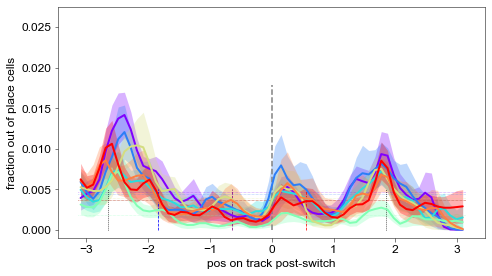

In [134]:
## Track-relative, or all days together
smooth_histogram = True
daylist= exp_days #[3,5,7,8,10,12,14]
colors = cm.rainbow(np.linspace(0,1,len(daylist)))

circ_bins = ((maxmax_pos - min_pos)/lin_bin_size)
bin_size = (2*np.pi)/((maxmax_pos - min_pos)/lin_bin_size)
bin_edges = np.linspace(-np.pi, np.pi, int(circ_bins))
bin_centers = bin_edges[:-1]+bin_size/2

collect_seq = {}

start_tele = np.hstack([aligned_start_circ_pos[:, np.newaxis],aligned_tele_circ_pos[:, np.newaxis]])

for ct in ['TR']:

    fig,ax = plt.subplots(figsize=(7,4))
    
    for d_i,day in enumerate(daylist):
        
        an_to_use = miniDayData[day].anim_list
            

        n_all_cells = np.sum([len(miniDayData[day].keep_masks[an]) for an in an_to_use]) # n all cells
        n_place_cells = np.sum([np.sum(miniDayData[day].keep_masks[an]) for an in an_to_use])
        n_seq = [len(mean_seq_pos[ct][day][an]) for an in an_to_use]

        ## Get means across each animals unity hist, normalized to cells within each animal

        hist_mat = np.hstack([np.expand_dims((np.histogram(mean_seq_pos[ct][day][an], 
                                                       bins=bin_edges)[0] / np.sum(
            miniDayData[day].keep_masks[an])), 
                               axis=1)
                for an in an_to_use])
        yax = 'fraction out of place cells'

        n_total = n_place_cells

        # chance = mean fraction of pcs within animal comprised by the sequence, 
        # divided by the number of bins
        seq_of_pcs_list = [len(mean_seq_pos[ct][day][an])/np.sum(miniDayData[day].keep_masks[an]) for an in an_to_use]
        chance = np.mean(seq_of_pcs_list)/len(bin_centers)

        collect_seq[day] = pd.DataFrame(ut.nansmooth(hist_mat.T, 1, axis=1), columns=bin_centers)
        collect_seq[day]['mouse_num'] = an_to_use
        collect_seq[day]['switch'] = np.repeat(exp_days.index(day)+1, len(an_to_use))
        
        hist_mean = np.nanmean(hist_mat,axis=1)
        hist_sem = ut.sem(hist_mat,axis=1)

        # ax[2].plot(bin_centers, ut.nansmooth(hist_norm_to_all,1), color = colors[d_i,:], linestyle = '--') 

        ## Plot histograms:
        if smooth_histogram:
            pt.plot_mean_sem(ax, ut.nansmooth(hist_mean,1), ut.nansmooth(hist_sem,1),xvalues=bin_centers,color = colors[d_i,:])
        else:
            pt.plot_mean_sem(ax, hist_mean, hist_sem,xvalues=bin_centers,color = colors[d_i,:])

        # ax[2].plot(bin_centers, ut.nansmooth(hist_mean,1), color = colors[d_i,:])


        ax.hlines(chance, -np.pi, np.pi, linestyle=":", color=colors[d_i,:], alpha=0.8, linewidth=0.5)

    ax.set_ylabel(yax)
    ylim = ax.get_ylim()[-1]
    if ct=='RR':
        if celltype=='disappear':
            ax.set_xlabel('pos rel to reward pre-switch')
        else:
            ax.set_xlabel('pos rel to reward post-switch')
        rdist = circ.phase_diff(spatial.pos_cm_to_rad(50, maxmax_pos, min_pos), spatial.pos_cm_to_rad(0, maxmax_pos, min_pos))
        ax.vlines(-rdist,0, ylim,linestyle=':',color='grey')
        ax.vlines(rdist,0, ylim,linestyle=':',color='grey')
        for ii in range(len(np.unique(start_tele, axis=0))):
            ax.vlines(np.unique(start_tele, axis=0)[ii,1], 0+(0.005*ii), 0.005+(0.001*ii), color = 'firebrick', alpha=0.5)
            ax.vlines(np.unique(start_tele, axis=0)[ii,0], 0+(0.005*ii), 0.005+(0.001*ii), color = 'seagreen', alpha=0.5)
    else:
        if celltype=='disappear':
            ax.set_xlabel('pos on track pre-switch')
        else:
            ax.set_xlabel('pos on track post-switch')

        # plot reward locs
        ax.vlines(spatial.pos_cm_to_rad(80, maxmax_pos,min_pos),0, 0.005, color='blue', linestyle='--', linewidth=0.75)
        ax.vlines(spatial.pos_cm_to_rad(200, maxmax_pos,min_pos),0, 0.005, color='purple', linestyle='--', linewidth=0.75)
        ax.vlines(spatial.pos_cm_to_rad(320, maxmax_pos,min_pos),0, 0.005, color='red', linestyle='--', linewidth=0.75)
        
        # plot track start and teleport
        ax.vlines(spatial.pos_cm_to_rad(450, maxmax_pos,min_pos),0, 0.005, color='black', linestyle=':', linewidth=0.75)
        ax.vlines(spatial.pos_cm_to_rad(0, maxmax_pos,min_pos),0, 0.005, color='black', linestyle=':', linewidth=0.75)
        
    ax.vlines(0,0, ax.get_ylim()[-1],linestyle='--',color='grey')    
    ax.set_ylim([-0.001, 0.0275])


    save_figures = False
    if save_figures:

        pt.savefig(fig, fig_dir, "%s_expday%s_RainbowCurves-%s_%s_post-switch_incTeleport_wTeleStartEndRedtoGreen" % (
            ut.make_anim_tag(an_to_use),ut.make_day_tag(daylist), ct, normtag)
               )

In [133]:
collect_seq[3]

,-3.091726103532812,-2.9903844050299155,-2.889042706527019,-2.7877010080241225,-2.686359309521226,-2.5850176110183294,-2.483675912515433,-2.3823342140125363,-2.2809925155096398,-2.1796508170067432,...,2.380725615623602,2.482067314126498,2.583409012629395,2.684750711132291,2.786092409635188,2.887434108138084,2.988775806640981,3.090117505143877,mouse_num,switch
0,0.003401,0.003538,0.004272,0.006042,0.008090,0.009340,0.011078,0.012900,0.011636,0.009781,...,0.003768,0.004285,0.002320,4.983733e-04,0.00004,1.209768e-06,0.000000,0.0,GCAMP15,0
1,0.003146,0.004887,0.004561,0.005888,0.012096,0.017142,0.016326,0.013898,0.012841,0.010609,...,0.003753,0.003634,0.001802,3.739134e-04,0.00003,8.892400e-07,0.000000,0.0,GCAMP17,0
2,0.003084,0.003385,0.003732,0.004822,0.007454,0.010758,0.014336,0.014916,0.012424,0.008987,...,0.006298,0.010072,0.011816,6.394598e-03,0.00137,1.108466e-04,0.000003,0.0,GCAMP18,0
3,0.005986,0.005967,0.006447,0.008065,0.011050,0.011524,0.013054,0.014873,0.012609,0.009674,...,0.001409,0.000231,0.000016,4.567598e-07,0.00000,0.000000e+00,0.000000,0.0,GCAMP19,0


In [136]:
df_src_seq = pd.DataFrame()

for d in exp_days:
    
    df_src_seq = df_src_seq.append(collect_seq[d], ignore_index=True)
    
ut.write_source_csv(df_src_seq, "Ext5d")

writing /data/2P/source_data/FigExt5d.csv


### Ext. Fig. 5j

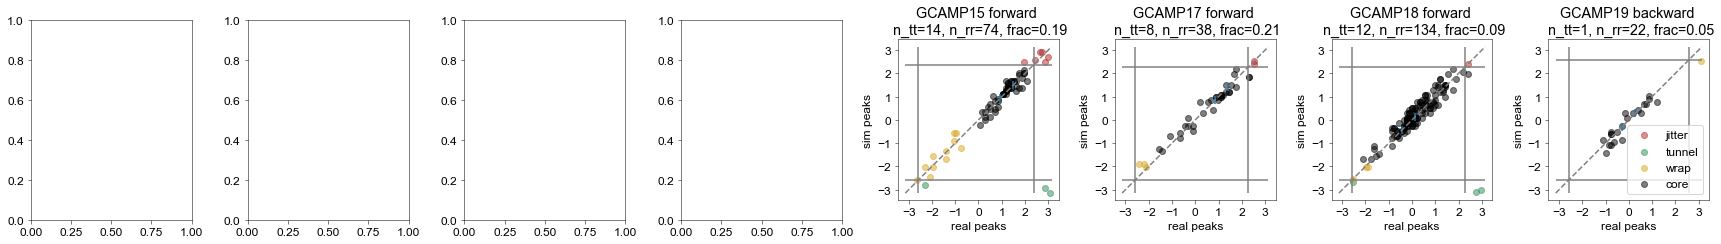

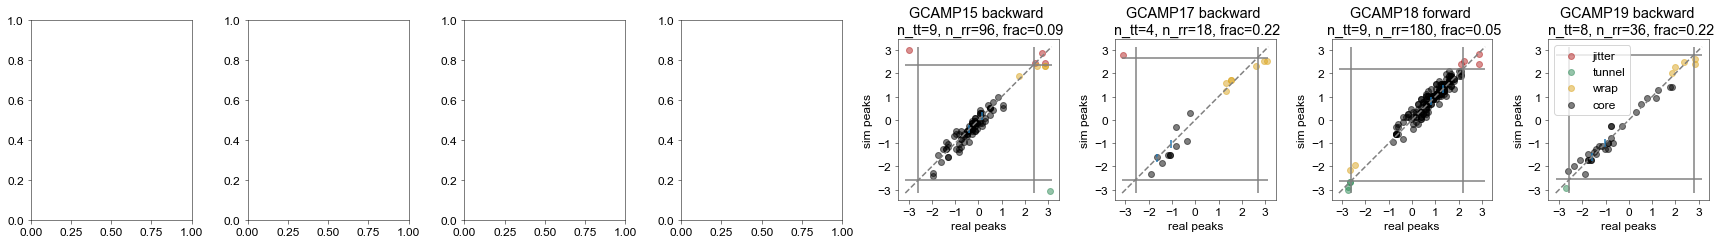

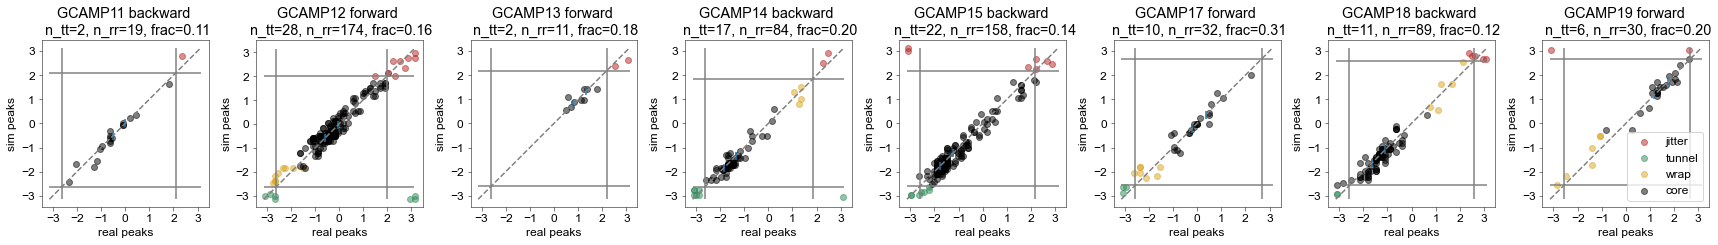

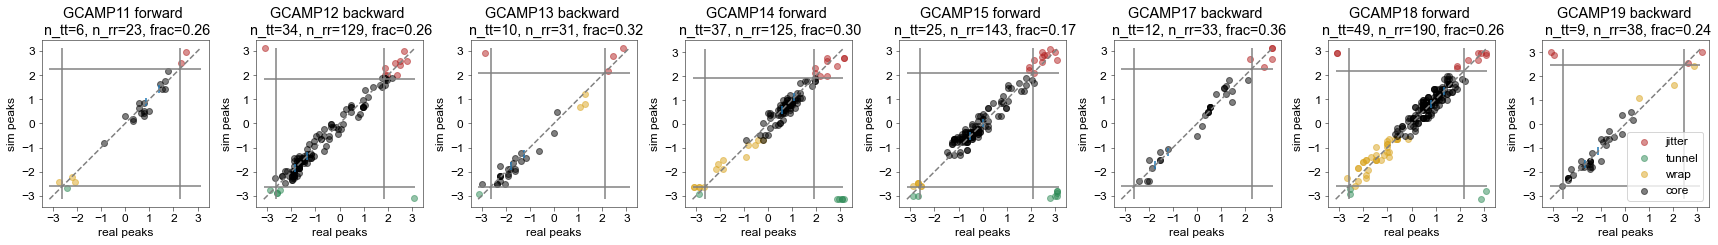

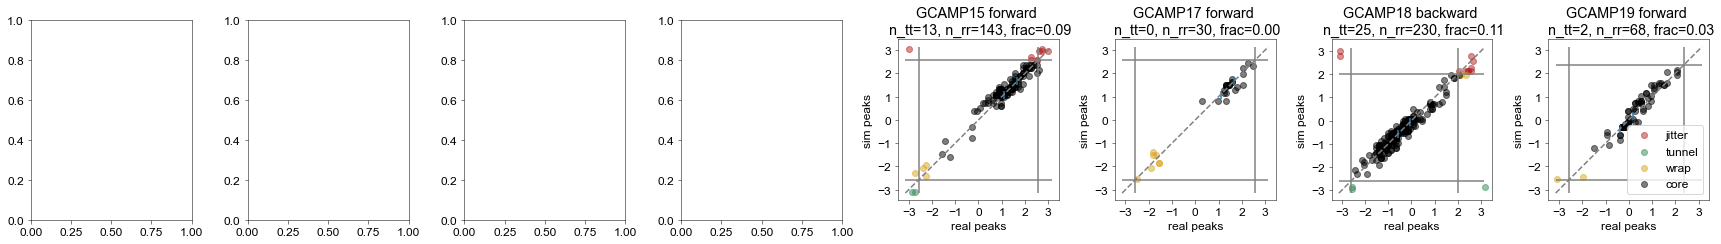

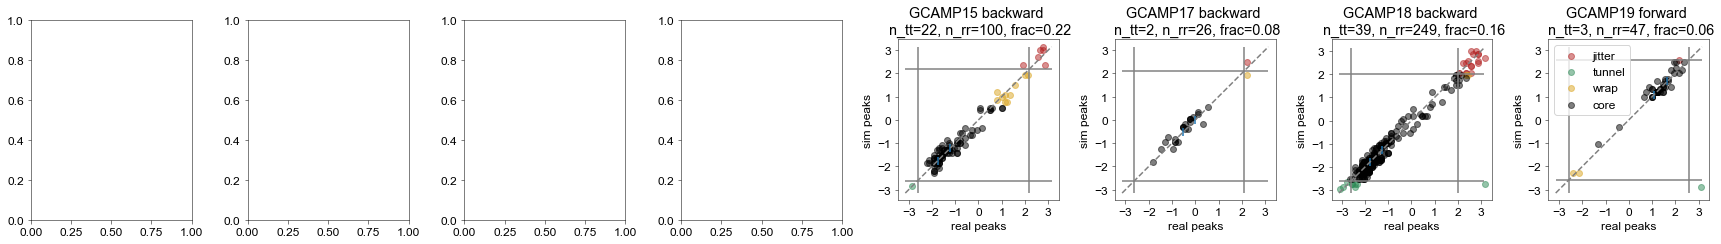

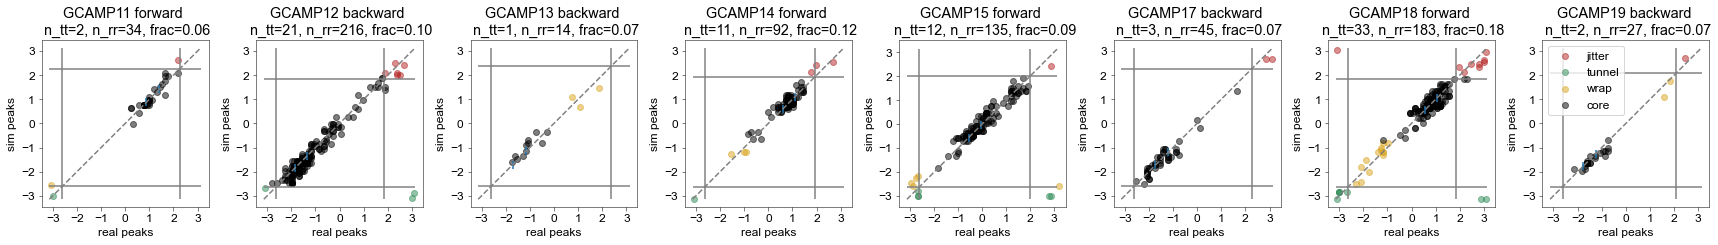

In [112]:
# if we add the reward shift distance to the peaks before, how many should have shifted into the teleport
# vs how many actually shifted
cols = ['mouse', 'day', 'switch', 'switch_dir', 'frac_RR_in_teleporttunnel', 'frac_TR_in_teleporttunnel',
        'n_RR', 'n_TR']
frac_tt_df = pd.DataFrame(data=np.zeros(
    (len(exp_days)*len(include_ans), len(cols)))*np.nan, columns=cols)
frac_tt_df['mouse'] = np.tile(include_ans, (len(exp_days), 1)).ravel()
frac_tt_df['day'] = np.repeat(exp_days, len(include_ans))
frac_tt_df['switch'] = np.repeat(np.arange(len(exp_days)), len(include_ans))

wrap_cols = ['mouse', 'day', 'switch', 'switch_dir', 'cell',
             'real_peak1', 'sim_peak1', 'real_minus_sim', 'real_minus_sim_linear', 'sim_remap_loc', 'real_remap_loc']
wrap_rr_df = pd.DataFrame(columns=wrap_cols)

for day in exp_days:
    fig, ax = plt.subplots(1, len(include_ans),
                           figsize=(3*len(include_ans), 3.5))

    for an_i, an in enumerate(include_ans):

        if an in miniDayData[day].anim_list:
            # % of rr cells with a peak in the teleport either before or after
            # look up end of track position in the original pos bin centers
 
            tm_bin_centers = miniDayData[day].circ_trial_matrix[an][-1]
            lin_pos_bin_centers = miniDayData[day].activity_matrix[an][-1]
            max_pos = miniDayData[day].activity_matrix[an][-2][-1]
            min_pos = miniDayData[day].activity_matrix[an][-2][0]
            tele_circ = spatial.pos_cm_to_rad(450, max_pos, min_pos)
            start_circ = spatial.pos_cm_to_rad(0, max_pos, min_pos)

            _, cell_inds = dd.get_cell_class_n(
                miniDayData, day, an, verbose=False)

            circ_peaks_0 = spatial.peak(np.nanmean(
                miniDayData[day].circ_map[an]['set 0'], axis=0),
                tm_bin_centers, axis=0)
            circ_peaks_1 = spatial.peak(np.nanmean(
                miniDayData[day].circ_map[an]['set 1'], axis=0),
                tm_bin_centers, axis=0)

            rr_circ_peaks_0 = circ_peaks_0[miniDayData[day].reward_rel_cell_ids[an]]
            rr_circ_peaks_1 = circ_peaks_1[miniDayData[day].reward_rel_cell_ids[an]]

            tr_circ_peaks_0 = circ_peaks_0[cell_inds['track']]
            tr_circ_peaks_1 = circ_peaks_1[cell_inds['track']]

            n_rr = len(miniDayData[day].reward_rel_cell_ids[an])
            n_tr = len(cell_inds['track'])
            
            # n w peak in teleport jitter or tunnel, before or after
            n_rr_in_teleport = np.sum(np.logical_or(((rr_circ_peaks_0 > tele_circ) |
                                                        (rr_circ_peaks_1 > tele_circ)),
                                                       ((rr_circ_peaks_0 < start_circ) |
                                                        (rr_circ_peaks_1 < start_circ))
                                                       ))
            n_tr_in_teleport = np.sum(np.logical_or(((tr_circ_peaks_0 > tele_circ) |
                                                        (tr_circ_peaks_1 > tele_circ)),
                                                       ((tr_circ_peaks_0 < start_circ) |
                                                        (tr_circ_peaks_1 < start_circ))
                                                       ))

            frac_rr_in_teleport = n_rr_in_teleport / n_rr

            frac_tr_in_teleport = n_tr_in_teleport / n_tr

       
            this_df_idx = ((frac_tt_df['mouse'] == an)
                           & (frac_tt_df['day'] == day))

            frac_tt_df.loc[this_df_idx,
                           'frac_RR_in_teleporttunnel'] = frac_rr_in_teleport
            frac_tt_df.loc[this_df_idx,
                           'frac_TR_in_teleporttunnel'] = frac_tr_in_teleport
            frac_tt_df.loc[this_df_idx, 'n_RR'] = n_rr
            frac_tt_df.loc[this_df_idx, 'n_TR'] = n_tr

            if miniDayData[day].rzone_pos[an]['set 1'][0] > miniDayData[day].rzone_pos[an]['set 0'][0]:
                frac_tt_df.loc[this_df_idx, 'switch_dir'] = 'forward'
            elif miniDayData[day].rzone_pos[an]['set 1'][0] < miniDayData[day].rzone_pos[an]['set 0'][0]:
                frac_tt_df.loc[this_df_idx, 'switch_dir'] = 'backward'

            rzone0 = miniDayData[day].rzone_pos[an]['set 0']
            rzone1 = miniDayData[day].rzone_pos[an]['set 1']
            circ_rzone0 = spatial.pos_cm_to_rad(
                rzone0, max_pos, min_pos)
            circ_rzone1 = spatial.pos_cm_to_rad(
                rzone1, max_pos, min_pos)

            if rzone1[0] > rzone0[0]:
                direction = 'forward'
   
                # look for cells that started after the reward,
                # and wrapped around to preced the reward zone, either on track or in teleport
                rzone_diff = circ_rzone1[0] - circ_rzone0[0]

                sim_rr_peaks_1 = circ.wrap(rr_circ_peaks_0 + rzone_diff)
                ## simulation
                sim_in_jitter = ((rr_circ_peaks_0 > circ_rzone0[-1]) &
                                 (sim_rr_peaks_1 > tele_circ))  # this should include cells that did not wrap around
                sim_wrapped_on_track = ((rr_circ_peaks_0 > circ_rzone0[-1]) &
                                        (sim_rr_peaks_1 < tele_circ) & (sim_rr_peaks_1 > start_circ) &
                                        (sim_rr_peaks_1 < circ_rzone1[0]))  # cells that wrapped onto the track
                sim_wrapped_in_tunnel = ((rr_circ_peaks_0 > circ_rzone0[-1]) &
                                         (sim_rr_peaks_1 < start_circ) &
                                         (sim_rr_peaks_1 < circ_rzone1[0]))  # cells that wrapped into the tunnel
                
                ## real
                real_in_jitter = ((rr_circ_peaks_0 > circ_rzone0[-1]) &
                                 (rr_circ_peaks_1 > tele_circ))  # this should include cells that did not wrap around
                real_wrapped_on_track = ((rr_circ_peaks_0 > circ_rzone0[-1]) &
                                        (rr_circ_peaks_1 < tele_circ) & (rr_circ_peaks_1 > start_circ) &
                                        (rr_circ_peaks_1 < circ_rzone1[0]))  # cells that wrapped onto the track
                real_wrapped_in_tunnel = ((rr_circ_peaks_0 > circ_rzone0[-1]) &
                                         (rr_circ_peaks_1 < start_circ) &
                                         (rr_circ_peaks_1 < circ_rzone1[0]))  # cells that wrapped into the tunnel

            if rzone1[0] < rzone0[0]:
                direction = 'backward'
                # print("backward_switch")
                # look for cells that started before the reward,
                # and wrapped around to follow the reward zone, either on track or in teleport
                rzone_diff = circ_rzone0[0] - circ_rzone1[0]

                sim_rr_peaks_1 = circ.wrap(rr_circ_peaks_0 - rzone_diff)
                ## simulation
                sim_in_jitter = ((rr_circ_peaks_0 < circ_rzone0[0]) &
                                 (sim_rr_peaks_1 > tele_circ))  # cells that wrapped into teleport jitter
                sim_wrapped_on_track = ((rr_circ_peaks_0 < circ_rzone0[0]) &
                                        (sim_rr_peaks_1 < tele_circ) &
                                        (sim_rr_peaks_1 > circ_rzone1[-1]))  # cells that wrapped onto the track
                sim_wrapped_in_tunnel = ((rr_circ_peaks_0 < circ_rzone0[0]) &
                                         (sim_rr_peaks_1 < start_circ))  # cells that shifted into the tunnel
                
                ## real
                real_in_jitter = ((rr_circ_peaks_0 < circ_rzone0[0]) &
                                 (rr_circ_peaks_1 > tele_circ))  # cells that wrapped into teleport jitter
                real_wrapped_on_track = ((rr_circ_peaks_0 < circ_rzone0[0]) &
                                        (rr_circ_peaks_1 < tele_circ) &
                                        (rr_circ_peaks_1 > circ_rzone1[-1]))  # cells that wrapped onto the track
                real_wrapped_in_tunnel = ((rr_circ_peaks_0 < circ_rzone0[0]) &
                                         (rr_circ_peaks_1 < start_circ)) 

            # now calc the difference between the simulated position and the actual position
            diff_from_sim_1 = rr_circ_peaks_1 - sim_rr_peaks_1

            this_df = pd.DataFrame({'mouse': np.repeat(an, (n_rr,)),
                                    'day': np.repeat(day, (n_rr,)),
                                    'switch': np.repeat(float(exp_days.index(day)), (n_rr,)),
                                    'switch_dir': np.repeat(direction, (n_rr,)),
                                    'cell': cell_inds['rr'],
                                    'real_peak1': rr_circ_peaks_1,
                                    'sim_peak1': sim_rr_peaks_1,
                                    'real_minus_sim': diff_from_sim_1,
                                    'real_minus_sim_linear': (lin_pos_bin_centers[ut.lookup_ind(rr_circ_peaks_1, tm_bin_centers)] -
                                                              lin_pos_bin_centers[ut.lookup_ind(sim_rr_peaks_1, tm_bin_centers)]),
                                    'sim_remap_loc': np.repeat('core', (n_rr,)),
                                    'real_remap_loc': np.repeat('core', (n_rr,)),
                                    })

            this_df.loc[sim_in_jitter, 'sim_remap_loc'] = 'jitter'
            this_df.loc[sim_wrapped_on_track, 'sim_remap_loc'] = 'wrap_track'
            this_df.loc[sim_wrapped_in_tunnel, 'sim_remap_loc'] = 'tunnel'
            this_df.loc[real_in_jitter, 'real_remap_loc'] = 'jitter'
            this_df.loc[real_wrapped_on_track, 'real_remap_loc'] = 'wrap_track'
            this_df.loc[real_wrapped_in_tunnel, 'real_remap_loc'] = 'tunnel'

            # ax[0].scatter(rr_circ_peaks_1, diff_from_sim_1, alpha=0.5)
            ax[an_i].scatter(rr_circ_peaks_1[sim_in_jitter],
                             sim_rr_peaks_1[sim_in_jitter], 
                             alpha=0.5, c='firebrick', label='jitter')
            ax[an_i].scatter(rr_circ_peaks_1[sim_wrapped_in_tunnel],
                             sim_rr_peaks_1[sim_wrapped_in_tunnel], 
                             alpha=0.5, c='seagreen', label='tunnel'
                            )
            ax[an_i].scatter(rr_circ_peaks_1[sim_wrapped_on_track],
                             sim_rr_peaks_1[sim_wrapped_on_track], 
                             alpha=0.5, c='goldenrod', label='wrap')
            ax[an_i].scatter(rr_circ_peaks_1[((~sim_in_jitter) & (~sim_wrapped_on_track) & (~sim_wrapped_in_tunnel))],
                             sim_rr_peaks_1[((~sim_in_jitter) & (~sim_wrapped_on_track) & (~sim_wrapped_in_tunnel))], 
                             alpha=0.5, c='black', label='core')
            ax[an_i].scatter(circ_rzone1, circ_rzone1, s=80, marker='|')

            teleport_cands = np.logical_or(((rr_circ_peaks_0 > tele_circ) |
                                            (rr_circ_peaks_1 > tele_circ)),
                                           ((rr_circ_peaks_0 < start_circ) |
                                            (rr_circ_peaks_1 < start_circ)))
        
            ax[an_i].plot([-np.pi, np.pi], [-np.pi, np.pi],
                          color='grey', linestyle='--')
            ax[an_i].hlines(tele_circ, -np.pi, np.pi, 'grey')
            ax[an_i].vlines(tele_circ, -np.pi, np.pi, 'grey')
            ax[an_i].hlines(start_circ, -np.pi, np.pi, 'grey')
            ax[an_i].vlines(start_circ, -np.pi, np.pi, 'grey')
            ax[an_i].set_xticks([-3,-2,-1,0,1,2,3])
            ax[an_i].set_yticks([-3,-2,-1,0,1,2,3])
            ax[an_i].set_xlabel('real peaks')
            ax[an_i].set_ylabel('sim peaks')
          
            ax[an_i].set_title("%s %s \n n_tt=%d, n_rr=%d, frac=%.2f" % (an, direction, n_rr_in_teleport, n_rr, frac_rr_in_teleport))

            ax[an_i].axis('square')
            
            wrap_rr_df = wrap_rr_df.append(this_df, ignore_index=True)

    ax[an_i].legend()
    
    
    save_figures=False
    if save_figures:
        pt.savefig(fig, fig_dir, "%s_expday%s_RR-peaks-vs-sim-peaks_set1_incTeleport" % (
            ut.make_anim_tag(include_ans),day)
               )
            # ax2[an_i].scatter(rr_circ_peaks_0[teleport_cands], rr_circ_peaks_1[teleport_cands], alpha=0.5, c='green')

### Ext. Fig. 5k

In [123]:
frac_real_of_sim_backward = np.zeros((4,4))*np.nan
frac_real_of_sim_forward = np.zeros((4,4))*np.nan

keys = ['core','wrap_track','tunnel','jitter']

count_real_b = np.zeros((4,1))*np.nan
count_sim_b = np.zeros((1,4))*np.nan
count_real_f = np.zeros((4,1))*np.nan
count_sim_f = np.zeros((1,4))*np.nan

# count how many that were supposed to be "sim" AND were "real" out of 
# how many were supposed to be "sim" (normalize by rows, which are sim)
for s_i, sim in enumerate(keys):
    for r_i, real in enumerate(keys):
        
        frac_real_of_sim_backward[s_i, r_i] = ((wrap_rr_df[wrap_rr_df['switch_dir']=='backward']['sim_remap_loc'] == sim) &
                                               (wrap_rr_df[wrap_rr_df['switch_dir']=='backward']['real_remap_loc'] == real)).sum()/ \
                                                (wrap_rr_df[wrap_rr_df['switch_dir']=='backward']['sim_remap_loc'] == sim).sum()
        frac_real_of_sim_forward[s_i, r_i] = ((wrap_rr_df[wrap_rr_df['switch_dir']=='forward']['sim_remap_loc'] == sim) &
                                               (wrap_rr_df[wrap_rr_df['switch_dir']=='forward']['real_remap_loc'] == real)).sum()/ \
                                                (wrap_rr_df[wrap_rr_df['switch_dir']=='forward']['sim_remap_loc'] == sim).sum()
    

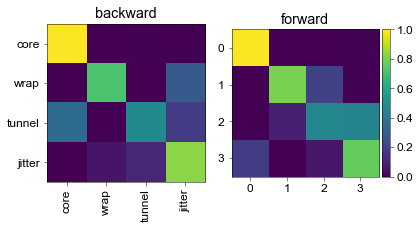

In [125]:
fig, ax = plt.subplots(1,2)
h0= ax[0].imshow(frac_real_of_sim_backward, cmap='viridis', vmin=0, vmax=1)
h1= ax[1].imshow(frac_real_of_sim_forward, cmap='viridis', vmin=0, vmax=1)
ax[0].set_title('backward')
ax[1].set_title('forward')
ax[0].set_xticks(np.arange(0,4))
ax[0].set_yticks(np.arange(0,4))
ax[0].set_xticklabels(['core','wrap','tunnel','jitter'],rotation=90)
ax[0].set_yticklabels(['core','wrap','tunnel','jitter'])


pt.colorbar(h1)
save_figures=False
if save_figures:
    pt.savefig(fig, fig_dir, "%s_allexpdays_frac_RR-peaks-vs-sim-peaks_set1_incTeleport_rowNorm" % (
        ut.make_anim_tag(include_ans))
           )

In [144]:
src_2dhist = pd.DataFrame(np.vstack([frac_real_of_sim_backward, frac_real_of_sim_forward]), 
                          columns = ['remain_on_track','wrap','tunnel','jitter'])
src_2dhist.index = np.tile(['remain_on_track','wrap','tunnel','jitter'],2)
src_2dhist['switch_direction'] = np.hstack([np.repeat('backward',4),
                                           np.repeat('forward',4)
                                           ])
ut.write_source_csv(src_2dhist, "Ext5k")

writing /data/2P/source_data/FigExt5k.csv


# Ext. Fig. 2e-f: correlate trial to trial firing error with distance run in prev teleport

loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday3_speed2_perms100_maximin_events.pickle
loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday5_speed2_perms100_maximin_events.pickle
loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday7_speed2_perms100_maximin_events.pickle
loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday8_speed2_perms100_maximin_events.pickle
loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday10_speed2_perms100_maximin_events.pickle
loading multi anim sess with default params
/data/2P/toShare/cleaned_w_F/2-3-4-6-7-10-11-12-13-14-15-17-18-19_expday12_speed2_perms100_maximin_events.pickle
loading multi anim sess with default params
/data/2P/toShare/c

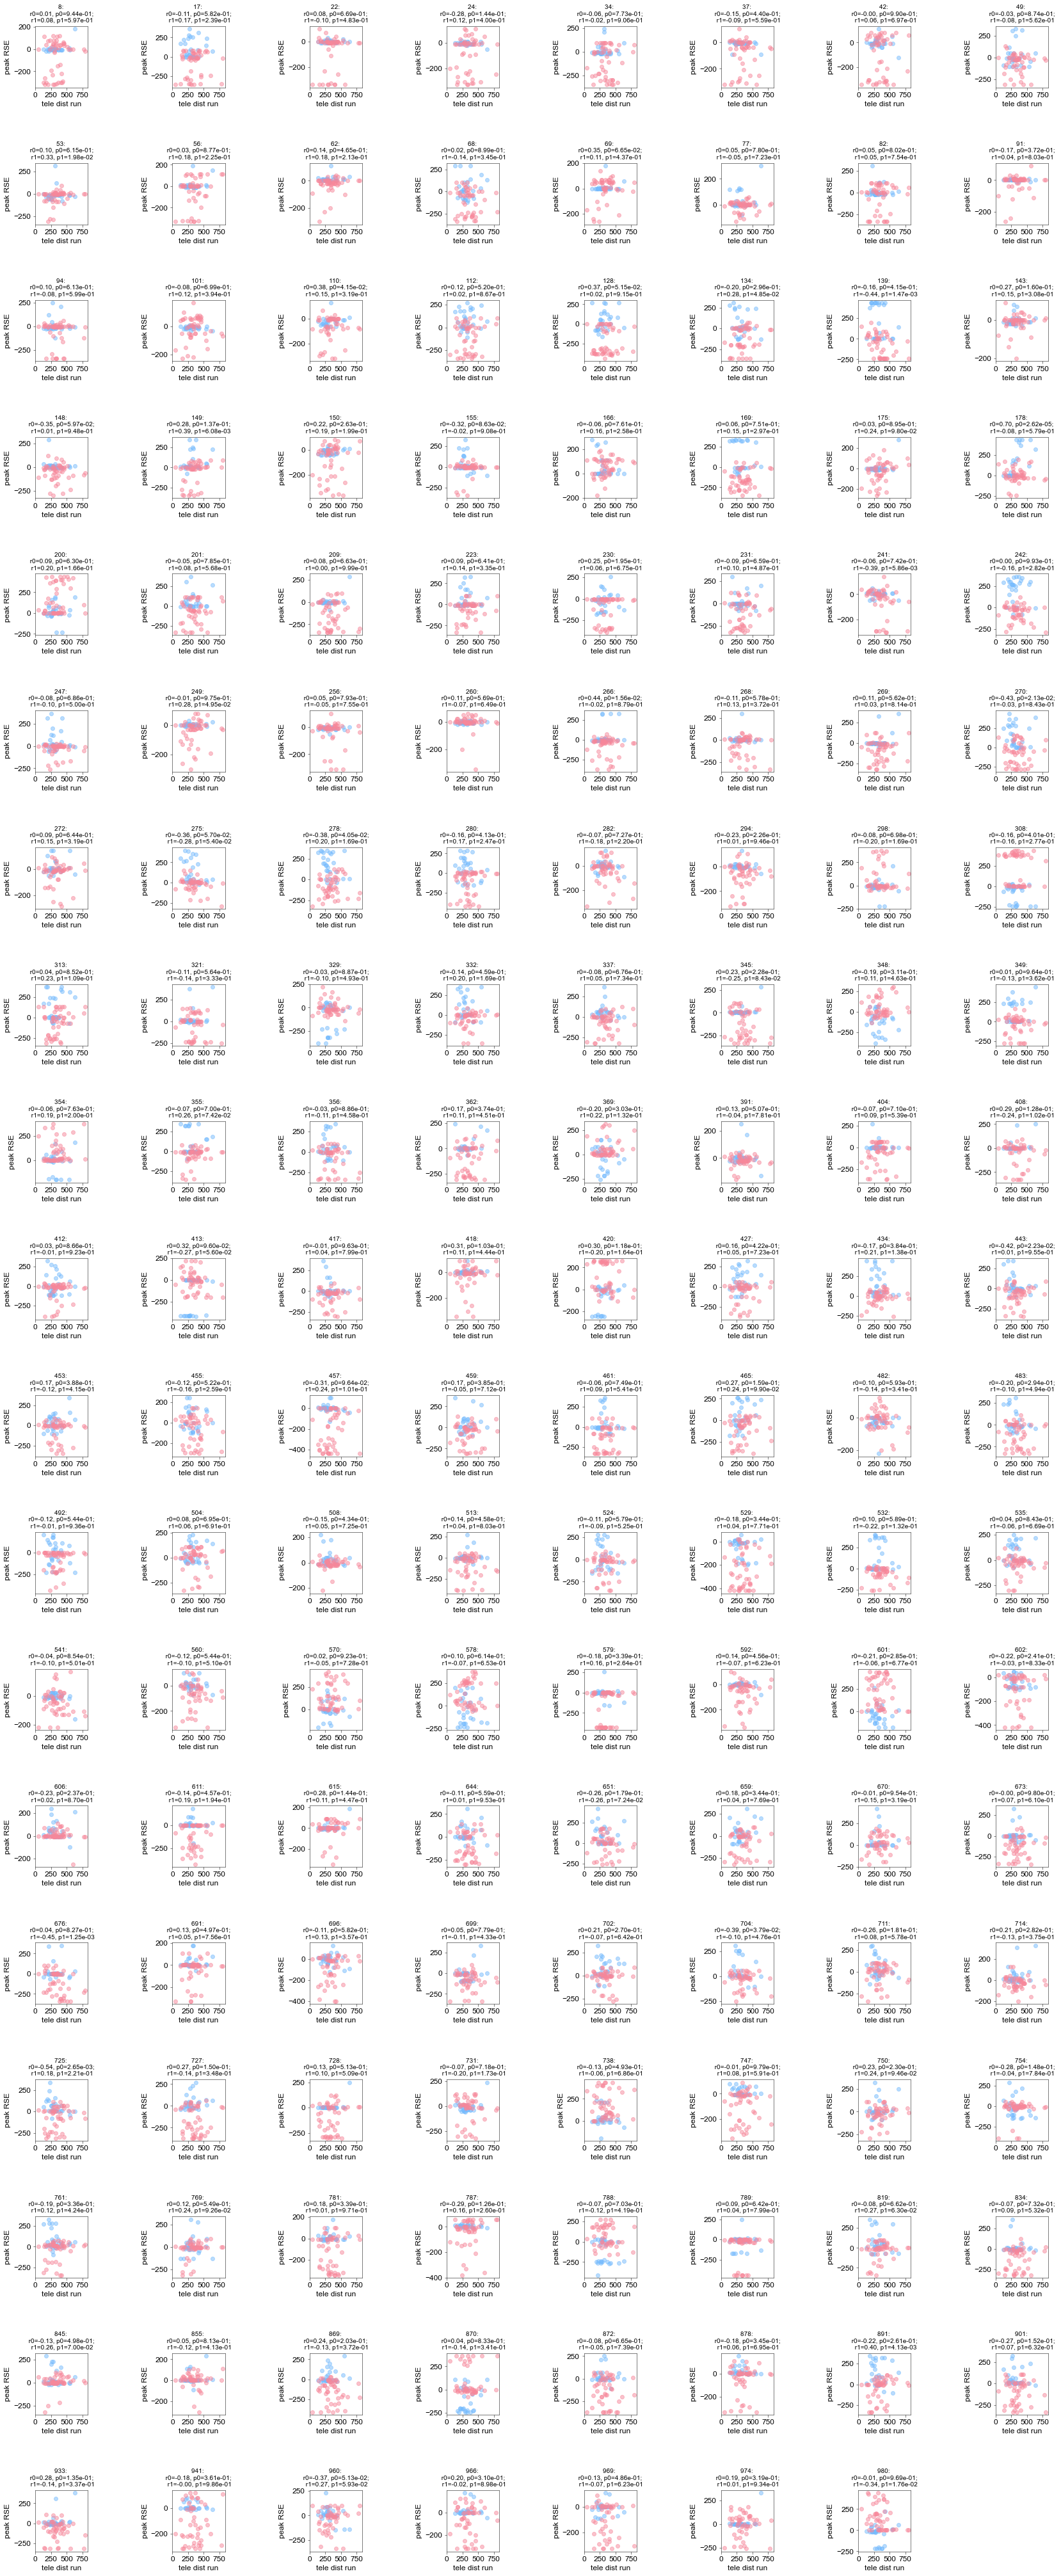

In [126]:
include_ans = ['GCAMP3', 'GCAMP4', 'GCAMP7', 'GCAMP11', 'GCAMP12', 'GCAMP13', 'GCAMP14',
               'GCAMP15', 'GCAMP17', 'GCAMP18', 'GCAMP19']

plot = False
use_circ = False

df_tdist = pd.DataFrame(
    columns=['day', 'mouse', 'cell', 'r0', 'r1', 'p0', 'p1'])

mean_tdist_run_0 = {}
mean_tdist_run_1 = {}

for day in exp_days:

    # Load pickle
    multi_anim_sess = ut.quick_load_multi_anim_sess(day)

    for an in include_ans:
        distance_dict, trials_to_keep = calc_teleport_run_distance_prev_trial(multi_anim_sess[an]['sess'],
                                                                              nbins=50, smooth=False, ts_key='dff')

        trials_to_keep_set0 = trials_to_keep[np.isin(trials_to_keep,
                                                     np.where(multi_anim_sess[an]['trial dict']['trial_set0'])[0])]
        trials_to_keep_set1 = trials_to_keep[np.isin(trials_to_keep,
                                                     np.where(multi_anim_sess[an]['trial dict']['trial_set1'])[0])]

        xstride = 3
        ystride = 3
        nperrow = 8

        tele_dist_run = np.zeros((len(distance_dict['tdist'].keys()),))*np.nan
        rr_cells = multiDayData[day].reward_rel_cell_ids[an]

        r0 = np.zeros((len(rr_cells),))*np.nan
        r1 = np.zeros((len(rr_cells),))*np.nan
        p0 = np.zeros((len(rr_cells),))*np.nan
        p1 = np.zeros((len(rr_cells),))*np.nan

        # example cell to plot
        if (an == 'GCAMP14') and (day == 8):
            plot = True
        else:
            plot = False
        if plot:
            fig = plt.figure(
                figsize=[nperrow*xstride, len(rr_cells)/nperrow*ystride])
            gs = gridspec.GridSpec(
                math.ceil(len(rr_cells)/nperrow)*ystride, xstride*nperrow)

        for i, trial in enumerate(distance_dict['tdist'].keys()):
            tele_dist_run[i] = (distance_dict['tdist'][trial][-1]-450)

        tele_dist_run_0 = tele_dist_run[np.isin(
            trials_to_keep, trials_to_keep_set0)]
        tele_dist_run_1 = tele_dist_run[np.isin(
            trials_to_keep, trials_to_keep_set1)]

        for c_i, c in enumerate(rr_cells):

            if use_circ:
                trial_peaks0 = spatial.peak(multiDayData[day].circ_trial_matrix[an][0][trials_to_keep_set0, :, c],
                                            multiDayData[day].circ_trial_matrix[an][-1],
                                            axis=1)
                mean_peak0 = spatial.peak(
                    np.nanmean(multiDayData[day].circ_trial_matrix[an][0][trials_to_keep_set0, :, c],
                               axis=0),
                    multiDayData[day].circ_trial_matrix[an][-1],
                )
                # convert circular error back to linear
                peak_diff_0 = spatial.dist_rad_to_cm(
                    circ.phase_diff(trial_peaks0, mean_peak0)
                )
            else:
                trial_peaks0 = spatial.peak(multiDayData[day].activity_matrix[an][trials_to_keep_set0, :, c],
                                            multiDayData[day].pos_bin_centers,
                                            axis=1)
                mean_peak0 = multiDayData[day].peaks[an]['set 0'][c]
        
                # signed distance
                peak_diff_0 = trial_peaks0 - mean_peak0

            if use_circ:
                trial_peaks1 = spatial.peak(multiDayData[day].circ_trial_matrix[an][0][trials_to_keep_set1, :, c],
                                            multiDayData[day].circ_trial_matrix[an][-1],
                                            axis=1)
                mean_peak1 = spatial.peak(
                    np.nanmean(multiDayData[day].circ_trial_matrix[an][0][trials_to_keep_set1, :, c],
                               axis=0),
                    multiDayData[day].circ_trial_matrix[an][-1],
                )
                peak_diff_1 = spatial.dist_rad_to_cm(
                    circ.phase_diff(trial_peaks1, mean_peak1)
                )
            else:
                trial_peaks1 = spatial.peak(multiDayData[day].activity_matrix[an][trials_to_keep_set1, :, c],
                                            multiDayData[day].pos_bin_centers,
                                            axis=1)
                mean_peak1 = multiDayData[day].peaks[an]['set 1'][c]
    
                # signed distance
                peak_diff_1 = trial_peaks1 - mean_peak1

            r0[c_i], p0[c_i] = sp.stats.spearmanr(tele_dist_run_0, peak_diff_0)
            r1[c_i], p1[c_i] = sp.stats.spearmanr(tele_dist_run_1, peak_diff_1)

            if plot:
                # add plots
                row_i = int(ystride*math.floor(c_i/nperrow))
                col_i = int(xstride*(c_i % nperrow))

                # specifiy which grid to plot cells
                c_ax = fig.add_subplot(
                    gs[row_i:row_i+ystride-1, col_i:col_i+xstride-1])
                c_ax.scatter(tele_dist_run_0, peak_diff_0,
                             c='xkcd:sky blue', alpha=0.5)
                c_ax.scatter(tele_dist_run_1, peak_diff_1,
                             c='xkcd:rose pink', alpha=0.5)

                c_ax.set_title("%d: \n r0=%.2f, p0=%.2e; \n r1=%.2f, p1=%.2e" % (c,
                                                                                 r0[c_i], p0[c_i],
                                                                                 r1[c_i], p1[c_i]),
                               fontsize=10)
                c_ax.set_xlabel('tele dist run')
                c_ax.set_xticks(np.arange(0, np.nanmax(tele_dist_run), 250))
                c_ax.set_ylabel('peak RSE')

        this_an_day_df = pd.DataFrame({'day': np.ones(len(r0,))*day,
                                       'mouse': np.repeat(an, len(r0)),
                                       'cell': rr_cells,
                                       'r0': r0,
                                       'r1': r1,
                                       'p0': p0,
                                       'p1': p1,
                                       })

        df_tdist = df_tdist.append(this_an_day_df, ignore_index=True)

        save_figure = False
        if save_figure and plot:
            if use_circ:
                pt.savefig(fig, fig_dir, ("%s_day%d_teleportDist-vs-peakCirctoLinError_RRcells" % (
                    an, day))
                )
            else:
                pt.savefig(fig, fig_dir, ("%s_day%d_teleportDist-vs-peakLinError_RRcells" % (
                    an, day))
                )

# %reset_selective -f multi_anim_sess

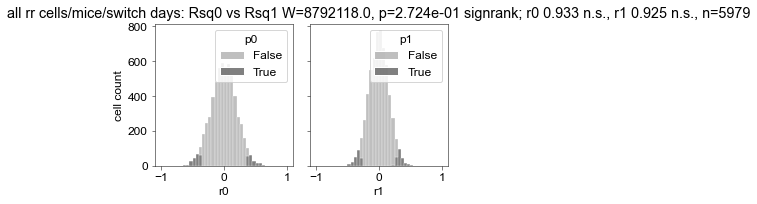

In [145]:
fig,ax = plt.subplots(1,2,figsize=(5,3), sharey=True)

r_bin_edges = np.arange(-1,1.1,0.05)

sns.histplot(data=df_tdist, ax=ax[0], stat="count", multiple="stack",
             x="r0", kde=False, binwidth = 0.05, binrange = (-1,1),
             palette="gray_r", hue=df_tdist['p0']<0.05,
             element="bars", legend=True)

sns.histplot(data=df_tdist, ax=ax[1], stat="count", multiple="stack",
             x="r1", kde=False, binwidth = 0.05, binrange = (-1,1),
             palette="gray_r", hue=df_tdist['p1']<0.05,
             element="bars", legend=True)

W, p = sp.stats.wilcoxon(df_tdist['r0'], df_tdist['r1'])
# sp.stats.ks_2samp(df_tdist['r0'], df_tdist['r1'])
ax[1].set_title('all rr cells/mice/switch days: Rsq0 vs Rsq1 W=%.1f, p=%.3e signrank; r0 %.3f n.s., r1 %.3f n.s., n=%d' % (
    W, p, (np.sum(df_tdist['p0']>=0.05) / len(df_tdist['r0'])), (np.sum(df_tdist['p1']>=0.05) / len(df_tdist['r1'])),
    len(df_tdist['r1'])))

ax[0].set_ylabel('cell count')

save_figures=False
if save_figures:
    pt.savefig(fig, fig_dir, ("%s_day%s_teleportDist-vs-peakError_RRcells_HistCorr-Lin-Signed" % (
                ut.make_anim_tag(include_ans), ut.make_day_tag(exp_days)))
                      )